# MerRec May 2023 — EDA rõ ràng, đủ 12 phần

Notebook này dành cho thư mục có **300+ file Parquet** MerRec tháng 05/2023.

Điểm thay đổi quan trọng so với bản cũ:

- `raw` và `events` chỉ là **DuckDB VIEW** → không copy/materialize lại toàn bộ ~20–23 GB.
- Chỉ materialize các bảng tổng hợp nhỏ hơn: user/item/session/sequence.
- Kiểm tra schema bằng **Parquet footer** trước, nhanh hơn nhiều.
- Không load toàn bộ data vào Pandas.
- Các phép rất nặng được để tùy chọn bằng `RUN_HEAVY = False`.

## 12 phần
1. Cấu trúc dataset
2. Dataset overview
3. Data quality
4. Event EDA
5. User behavior
6. Item behavior
7. Session EDA
8. Sequence EDA / SASRec
9. Temporal EDA
10. Product metadata EDA
11. Price EDA
12. Recommendation diagnostics

## 0. Cấu hình

In [1]:
# Nếu thiếu thư viện:
# %pip install duckdb pyarrow pandas numpy matplotlib

from pathlib import Path
import os
import warnings

import duckdb
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# ============================================================
# ĐƯỜNG DẪN DATASET
# ============================================================
DATA_PATH = Path(r"D:\MerRec\data\raw\20230501")

# Tách database, spill, CSV và biểu đồ giữa các kernel Python.
# Kết quả từ kernel trước vẫn giữ nguyên trong thư mục của kernel đó.
OUTPUT_ROOT = DATA_PATH.parents[1] / "processed" / "eda_merrec_may"
OUT_DIR = OUTPUT_ROOT / f"kernel_{os.getpid()}"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
TEMP_DIR = OUT_DIR / "duckdb_temp"

for p in [OUT_DIR, FIG_DIR, TABLE_DIR, TEMP_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# False = toàn bộ 300+ file
# True = chỉ vài file để debug nhanh
TEST_MODE = False
TEST_N_FILES = 10

# Chỉ bật nếu thật sự cần giải mã toàn bộ data pages của từng parquet.
FULL_PARQUET_VALIDATION = False

# Exact duplicate toàn row / metadata conflict rất nặng.
RUN_HEAVY = False

# Chỉ dùng EPOCH_UNIT khi stime là số/chuỗi số. Timestamp Parquet giữ nguyên kiểu.
EPOCH_UNIT = "ms"

# Split chẩn đoán; chỉnh sau khi xem Temporal EDA.
TRAIN_END = "2023-05-26"
VAL_END = "2023-05-29"

print("DATA_PATH:", DATA_PATH)
print("OUT_DIR :", OUT_DIR)

DATA_PATH: D:\MerRec\data\raw\20230501
OUT_DIR : D:\MerRec\data\processed\eda_merrec_may\kernel_17888


### Database riêng cho mỗi kernel
Kết quả được lưu trong `eda_merrec_may/kernel_<PID>/`. Các kernel khác nhau không mở chung file DuckDB hoặc ghi đè CSV/PNG của nhau.
Khi restart kernel, PID thay đổi nên cần chạy lại từ đầu. Muốn xem kết quả cũ, mở thư mục kernel cũ; notebook không tự xóa các thư mục này.
Nếu vừa cập nhật cell này để sửa lỗi khóa file, chạy lại từ **0. Cấu hình** xuống dưới để tạo lại các bảng trong database mới.


In [2]:
# ============================================================
# DUCKDB + HÀM PHỤ
# ============================================================

if "con" in globals():
    con.close()

DB_PATH = OUT_DIR / "merrec_eda.duckdb"
con = duckdb.connect(str(DB_PATH))
print("Kernel PID:", os.getpid())
print("Database:", DB_PATH)
con.execute(f"SET threads={max(1, min(6, (os.cpu_count() or 4) - 1))}")
con.execute("SET temp_directory='" + TEMP_DIR.as_posix().replace("'", "''") + "'")
con.execute("SET preserve_insertion_order=false")

def q(sql):
    return con.execute(sql).df()

def scalar(sql):
    return con.execute(sql).fetchone()[0]

def show_table(name, df, n=20):
    df.to_csv(TABLE_DIR / f"{name}.csv", index=False, encoding="utf-8-sig")
    print(f"{name}: {len(df):,} dòng")
    display(df.head(n))
    return df

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def bar(df, x, y, title, name, horizontal=False, log_y=False):
    if df.empty:
        return
    plt.figure(figsize=(10, 5))
    if horizontal:
        plt.barh(df[x].astype(str), df[y])
        plt.gca().invert_yaxis()
        plt.xlabel(y)
    else:
        plt.bar(df[x].astype(str), df[y])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(y)
    if log_y:
        plt.yscale("log")
    plt.title(title)
    savefig(name)

def heatmap(df, row, col, value, title, name):
    if df.empty:
        return
    p = df.pivot_table(index=row, columns=col, values=value, aggfunc="sum", fill_value=0)
    plt.figure(figsize=(12, max(4, len(p) * 0.35)))
    plt.imshow(p.to_numpy(dtype=float), aspect="auto")
    plt.colorbar(label=value)
    plt.xticks(range(len(p.columns)), p.columns.astype(str), rotation=90)
    plt.yticks(range(len(p.index)), p.index.astype(str))
    plt.title(title)
    savefig(name)

Kernel PID: 17888
Database: D:\MerRec\data\processed\eda_merrec_may\kernel_17888\merrec_eda.duckdb


# 1. Kiểm tra cấu trúc dataset

Kiểm tra số file, dung lượng, số row theo footer, schema, file lỗi, cột bắt buộc, kiểu ID/timestamp và 20 dòng mẫu.

Mặc định chỉ đọc **footer**. Đây là cách phù hợp với 300+ file Parquet và nhanh hơn việc giải mã toàn bộ file.

In [6]:
# ============================================================
# 1.1 FILE INVENTORY + SCHEMA
# ============================================================

all_files = sorted(DATA_PATH.glob("*.parquet"))
if not all_files:
    raise FileNotFoundError(f"Không tìm thấy parquet trong {DATA_PATH}")

files = all_files[:TEST_N_FILES] if TEST_MODE else all_files

file_rows = []
schema_rows = []

for i, fp in enumerate(files, 1):
    info = {
        "file": fp.name,
        "size_mb": fp.stat().st_size / 1024**2,
        "rows": None,
        "columns": None,
        "row_groups": None,
        "status": "OK",
        "error": None
    }

    try:
        pf = pq.ParquetFile(fp)
        schema = pf.schema_arrow

        info["rows"] = pf.metadata.num_rows
        info["columns"] = len(schema)
        info["row_groups"] = pf.metadata.num_row_groups

        for field in schema:
            schema_rows.append({
                "file": fp.name,
                "column": field.name,
                "dtype": str(field.type),
                "nullable": field.nullable
            })

        if FULL_PARQUET_VALIDATION:
            for batch in pf.iter_batches(batch_size=65536):
                batch.validate(full=True)

    except Exception as e:
        info["status"] = "ERROR"
        info["error"] = f"{type(e).__name__}: {e}"

    file_rows.append(info)

    if i % 50 == 0 or i == len(files):
        print(f"Đã kiểm tra {i}/{len(files)} file")

file_info = pd.DataFrame(file_rows)
schema_per_file = pd.DataFrame(schema_rows)

show_table("01_file_inventory", file_info)

Đã kiểm tra 50/312 file
Đã kiểm tra 100/312 file
Đã kiểm tra 150/312 file
Đã kiểm tra 200/312 file
Đã kiểm tra 250/312 file
Đã kiểm tra 300/312 file
Đã kiểm tra 312/312 file
01_file_inventory: 312 dòng


,file,size_mb,rows,columns,row_groups,status,error
0,000000000000.parquet,64.743526,504013,25,1,OK,None
1,000000000001.parquet,68.089210,525540,25,2,OK,None
2,000000000002.parquet,70.443246,554936,25,2,OK,None
3,000000000003.parquet,67.472311,526095,25,2,OK,None
4,000000000004.parquet,82.299263,660889,25,2,OK,None
5,000000000005.parquet,75.207989,610732,25,2,OK,None
6,000000000006.parquet,70.000411,553971,25,2,OK,None
7,000000000007.parquet,82.024287,659545,25,2,OK,None
8,000000000008.parquet,80.121362,643633,25,2,OK,None
9,000000000009.parquet,59.786047,465344,25,1,OK,None


,file,size_mb,rows,columns,row_groups,status,error
0,000000000000.parquet,64.743526,504013,25,1,OK,None
1,000000000001.parquet,68.089210,525540,25,2,OK,None
2,000000000002.parquet,70.443246,554936,25,2,OK,None
3,000000000003.parquet,67.472311,526095,25,2,OK,None
4,000000000004.parquet,82.299263,660889,25,2,OK,None
...,...,...,...,...,...,...,...
307,000000000307.parquet,83.435508,668617,25,2,OK,None
308,000000000308.parquet,64.919765,503428,25,1,OK,None
309,000000000309.parquet,64.509099,507556,25,1,OK,None
310,000000000310.parquet,72.300370,575791,25,2,OK,None


In [7]:
# ============================================================
# 1.2 TỔNG QUAN FILE + SCHEMA ĐỒNG NHẤT
# ============================================================

summary = pd.DataFrame([{
    "files_found": len(all_files),
    "files_used": len(files),
    "files_ok": int((file_info["status"] == "OK").sum()),
    "files_error": int((file_info["status"] == "ERROR").sum()),
    "total_rows_footer": int(file_info["rows"].fillna(0).sum()),
    "total_size_GB": file_info["size_mb"].sum() / 1024,
    "avg_file_MB": file_info["size_mb"].mean(),
    "max_file_MB": file_info["size_mb"].max()
}])

show_table("01_structure_summary", summary)
show_table("01_bad_files", file_info[file_info["status"] != "OK"])

schema_signature = (
    schema_per_file
    .groupby("file")
    .apply(lambda x: tuple(zip(x["column"], x["dtype"])), include_groups=False)
)

print("Số schema khác nhau:", schema_signature.nunique())
print("✅ Schema đồng nhất." if schema_signature.nunique() == 1
      else "⚠️ Có schema khác nhau giữa các file.")

01_structure_summary: 1 dòng


,files_found,files_used,files_ok,files_error,total_rows_footer,total_size_GB,avg_file_MB,max_file_MB
0,312,312,312,0,174872167,21.569851,70.793356,108.347322


01_bad_files: 0 dòng


,file,size_mb,rows,columns,row_groups,status,error


Số schema khác nhau: 1
✅ Schema đồng nhất.


In [8]:
# ============================================================
# 1.3 RAW VIEW — ĐỌC TRỰC TIẾP 300+ PARQUET
# ============================================================

valid_files = [
    fp for fp in files
    if fp.name in set(file_info.loc[file_info["status"] == "OK", "file"])
]

if not valid_files:
    raise RuntimeError("Không có file parquet đọc được.")

paths_sql = "[" + ",".join(
    "'" + fp.as_posix().replace("'", "''") + "'"
    for fp in valid_files
) + "]"

con.execute(f"""
CREATE OR REPLACE VIEW raw AS
SELECT *
FROM read_parquet(
    {paths_sql},
    union_by_name=true,
    filename=true,
    file_row_number=true
)
""")

raw_schema = q("DESCRIBE raw")
raw_columns = raw_schema["column_name"].tolist()

show_table("01_union_schema", raw_schema)

required = ["user_id", "item_id", "event_id", "stime", "session_id"]
required_check = pd.DataFrame({
    "column": required,
    "exists": [c in raw_columns for c in required]
})
show_table("01_required_columns", required_check)

if not required_check["exists"].all():
    raise ValueError("Thiếu cột bắt buộc.")

show_table("01_sample_20", q("SELECT * FROM raw LIMIT 20"), n=20)

01_union_schema: 27 dòng


,column_name,column_type,null,key,default,extra
0,user_id,BIGINT,YES,None,None,None
1,stime,TIMESTAMP,YES,None,None,None
2,session_id,VARCHAR,YES,None,None,None
3,sequence_id,VARCHAR,YES,None,None,None
4,sequence_length,BIGINT,YES,None,None,None
5,event_id,VARCHAR,YES,None,None,None
6,item_id,BIGINT,YES,None,None,None
7,product_id,VARCHAR,YES,None,None,None
8,name,VARCHAR,YES,None,None,None
9,price,DOUBLE,YES,None,None,None


01_required_columns: 5 dòng


,column,exists
0,user_id,True
1,item_id,True
2,event_id,True
3,stime,True
4,session_id,True


01_sample_20: 20 dòng


,user_id,stime,session_id,sequence_id,sequence_length,event_id,item_id,product_id,name,price,c0_name,c0_id,c1_name,c1_id,c2_name,c2_id,brand_name,brand_id,item_condition_id,item_condition_name,size_name,size_id,color,shipper_id,shipper_name,file_row_number,filename
0,328697,2023-05-13 20:27:11,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,35658057,327_215,altard state star slouchy sweater - retro funk...,10.0,Women,1097,Sweaters,215,None,<NA>,Altar'd State,327,3,Good,S (4-6),5,None,1,Buyer,524289,D:/MerRec/data/raw/20230501/000000000001.parquet
1,328697,2023-05-13 20:27:13,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_like,35658057,327_215,altard state star slouchy sweater - retro funk...,10.0,Women,1097,Sweaters,215,None,<NA>,Altar'd State,327,3,Good,S (4-6),5,None,1,Buyer,524290,D:/MerRec/data/raw/20230501/000000000001.parquet
2,328697,2023-05-13 20:27:33,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,95964237,24159_2194,VICTORIA'S SECRET Cotton Fleece Corset Tank To...,18.0,Women,1097,Tops & blouses,199,Tank Tops,2194,Victoria's Secret,24159,2,Like new,XS (0-2),4,None,1,Buyer,524291,D:/MerRec/data/raw/20230501/000000000001.parquet
3,328697,2023-05-13 20:27:39,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,62575741,7810_1101,Long sleeved tie up fuzzy crop top,8.0,Women,1097,Tops & blouses,199,Blouse,1101,Fashion Nova,7810,2,Like new,S (4-6),5,None,1,Buyer,524292,D:/MerRec/data/raw/20230501/000000000001.parquet
4,328697,2023-05-13 20:27:53,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,60096557,327_1101,Altard state bundle,35.0,Women,1097,Tops & blouses,199,Blouse,1101,Altar'd State,327,1,New,S (4-6),5,None,1,Buyer,524293,D:/MerRec/data/raw/20230501/000000000001.parquet
5,328697,2023-05-13 20:28:10,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,80465951,327_253,Altar'd State Radiant Bundle,20.0,Beauty,298,Skin care,253,None,<NA>,Altar'd State,327,1,New,None,<NA>,None,1,Buyer,524294,D:/MerRec/data/raw/20230501/000000000001.parquet
6,328697,2023-05-13 20:28:20,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,81184128,15901_1101,Nordstrom Altar’d State Alternative Apparel st...,4.0,Women,1097,Tops & blouses,199,Blouse,1101,Nordstrom,15901,3,Good,S (4-6),5,None,1,Buyer,524295,D:/MerRec/data/raw/20230501/000000000001.parquet
7,328697,2023-05-13 20:29:36,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,5758639,327_721,Altar’d State Crop Top XS,13.0,Women,1097,Tops & blouses,199,T-shirts,721,Altar'd State,327,2,Like new,XS (0-2),4,None,1,Buyer,524296,D:/MerRec/data/raw/20230501/000000000001.parquet
8,328697,2023-05-13 20:29:38,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_like,5758639,327_721,Altar’d State Crop Top XS,13.0,Women,1097,Tops & blouses,199,T-shirts,721,Altar'd State,327,2,Like new,XS (0-2),4,None,1,Buyer,524297,D:/MerRec/data/raw/20230501/000000000001.parquet
9,328704,2023-05-03 18:34:42,5d8f8463922d263e35fba3a525082034784005d04556f2...,20230501_0,21,item_view,9293638,0_2625,Neretva Espresso Coffee Maker Machine 15 Bar M...,160.0,Home,468,Kitchen Coffee & Espresso Makers,2474,Espresso & Cappuccino Machines,2625,None,0,2,Like new,None,<NA>,None,1,Buyer,524298,D:/MerRec/data/raw/20230501/000000000001.parquet


,user_id,stime,session_id,sequence_id,sequence_length,event_id,item_id,product_id,name,price,c0_name,c0_id,c1_name,c1_id,c2_name,c2_id,brand_name,brand_id,item_condition_id,item_condition_name,size_name,size_id,color,shipper_id,shipper_name,file_row_number,filename
0,328697,2023-05-13 20:27:11,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,35658057,327_215,altard state star slouchy sweater - retro funk...,10.0,Women,1097,Sweaters,215,None,<NA>,Altar'd State,327,3,Good,S (4-6),5,None,1,Buyer,524289,D:/MerRec/data/raw/20230501/000000000001.parquet
1,328697,2023-05-13 20:27:13,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_like,35658057,327_215,altard state star slouchy sweater - retro funk...,10.0,Women,1097,Sweaters,215,None,<NA>,Altar'd State,327,3,Good,S (4-6),5,None,1,Buyer,524290,D:/MerRec/data/raw/20230501/000000000001.parquet
2,328697,2023-05-13 20:27:33,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,95964237,24159_2194,VICTORIA'S SECRET Cotton Fleece Corset Tank To...,18.0,Women,1097,Tops & blouses,199,Tank Tops,2194,Victoria's Secret,24159,2,Like new,XS (0-2),4,None,1,Buyer,524291,D:/MerRec/data/raw/20230501/000000000001.parquet
3,328697,2023-05-13 20:27:39,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,62575741,7810_1101,Long sleeved tie up fuzzy crop top,8.0,Women,1097,Tops & blouses,199,Blouse,1101,Fashion Nova,7810,2,Like new,S (4-6),5,None,1,Buyer,524292,D:/MerRec/data/raw/20230501/000000000001.parquet
4,328697,2023-05-13 20:27:53,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,60096557,327_1101,Altard state bundle,35.0,Women,1097,Tops & blouses,199,Blouse,1101,Altar'd State,327,1,New,S (4-6),5,None,1,Buyer,524293,D:/MerRec/data/raw/20230501/000000000001.parquet
5,328697,2023-05-13 20:28:10,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,80465951,327_253,Altar'd State Radiant Bundle,20.0,Beauty,298,Skin care,253,None,<NA>,Altar'd State,327,1,New,None,<NA>,None,1,Buyer,524294,D:/MerRec/data/raw/20230501/000000000001.parquet
6,328697,2023-05-13 20:28:20,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,81184128,15901_1101,Nordstrom Altar’d State Alternative Apparel st...,4.0,Women,1097,Tops & blouses,199,Blouse,1101,Nordstrom,15901,3,Good,S (4-6),5,None,1,Buyer,524295,D:/MerRec/data/raw/20230501/000000000001.parquet
7,328697,2023-05-13 20:29:36,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_view,5758639,327_721,Altar’d State Crop Top XS,13.0,Women,1097,Tops & blouses,199,T-shirts,721,Altar'd State,327,2,Like new,XS (0-2),4,None,1,Buyer,524296,D:/MerRec/data/raw/20230501/000000000001.parquet
8,328697,2023-05-13 20:29:38,d5732b54422f25712760f76fe071f0dc46c804e5efa4b7...,20230501_9,22,item_like,5758639,327_721,Altar’d State Crop Top XS,13.0,Women,1097,Tops & blouses,199,T-shirts,721,Altar'd State,327,2,Like new,XS (0-2),4,None,1,Buyer,524297,D:/MerRec/data/raw/20230501/000000000001.parquet
9,328704,2023-05-03 18:34:42,5d8f8463922d263e35fba3a525082034784005d04556f2...,20230501_0,21,item_view,9293638,0_2625,Neretva Espresso Coffee Maker Machine 15 Bar M...,160.0,Home,468,Kitchen Coffee & Espresso Makers,2474,Espresso & Cappuccino Machines,2625,None,0,2,Like new,None,<NA>,None,1,Buyer,524298,D:/MerRec/data/raw/20230501/000000000001.parquet


In [9]:
# ============================================================
# 1.4 DATATYPE ID + TIMESTAMP
# ============================================================

check_cols = [
    "user_id", "item_id", "product_id",
    "session_id", "sequence_id", "event_id", "stime"
]

type_check = raw_schema[
    raw_schema["column_name"].isin(check_cols)
][["column_name", "column_type"]].copy()

type_check["review"] = np.where(
    type_check["column_type"].str.contains("FLOAT|DOUBLE", case=False, regex=True),
    "REVIEW: float có thể gây mất chính xác ID",
    "OK / kiểm tra theo ý nghĩa cột"
)

show_table("01_id_timestamp_types", type_check)

01_id_timestamp_types: 7 dòng


,column_name,column_type,review
0,user_id,BIGINT,OK / kiểm tra theo ý nghĩa cột
1,stime,TIMESTAMP,OK / kiểm tra theo ý nghĩa cột
2,session_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột
3,sequence_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột
5,event_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột
6,item_id,BIGINT,OK / kiểm tra theo ý nghĩa cột
7,product_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột


,column_name,column_type,review
0,user_id,BIGINT,OK / kiểm tra theo ý nghĩa cột
1,stime,TIMESTAMP,OK / kiểm tra theo ý nghĩa cột
2,session_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột
3,sequence_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột
5,event_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột
6,item_id,BIGINT,OK / kiểm tra theo ý nghĩa cột
7,product_id,VARCHAR,OK / kiểm tra theo ý nghĩa cột


## 1.5 Chuẩn hóa `events` bằng VIEW

Không còn `materialize('events', ...)`.

Mapping metadata:

- `c0_name → category0`
- `c1_name → category1`
- `c2_name → category2`
- `brand_name → brand`
- `item_condition_name → condition`
- `shipper_name → shipper`
- `size_name → size`

### Kiểm tra stime trước khi tạo events
            Timestamp/date được đọc trực tiếp; chỉ chuyển epoch với kiểu số/chuỗi số.
            Phân tích dùng UTC; timestamp không timezone được giả định là UTC.
            Nếu vừa sửa parser, chạy lại từ đây và các phần phía dưới để tạo lại
            user_stats, item_stats, session_stats, sequence_stats và các báo cáo/split.
            Kết quả thời gian và duplicate từ lần chạy parser cũ không còn đáng tin cậy.


In [10]:
def stime_expression(data_type, epoch_unit):
    data_type = data_type.upper()
    if data_type.startswith('TIMESTAMP') or data_type == 'DATE':
        return 'TRY_CAST(stime AS TIMESTAMP)'
    divisor = {'s': 1, 'ms': 1000, 'us': 1_000_000, 'ns': 1_000_000_000}[epoch_unit]
    epoch_sql = f'TRY(CAST(to_timestamp(TRY_CAST(stime AS DOUBLE) / {divisor}) AS TIMESTAMP))'
    if any(t in data_type for t in ['INT', 'DOUBLE', 'FLOAT', 'DECIMAL', 'REAL']):
        return epoch_sql
    # Chuỗi số dùng epoch unit; chuỗi ngày giờ dùng timestamp parser.
    return f"""CASE
        WHEN TRY_CAST(stime AS DOUBLE) IS NOT NULL THEN {epoch_sql}
        ELSE TRY_CAST(TRY_CAST(stime AS TIMESTAMPTZ) AS TIMESTAMP)
    END"""

con.execute("SET TimeZone='UTC'")
stime_type = q('DESCRIBE raw').set_index('column_name').loc['stime', 'column_type']
ts_sql = stime_expression(stime_type, EPOCH_UNIT)
print('stime dtype:', stime_type, '| epoch unit (chỉ áp dụng dữ liệu số):', EPOCH_UNIT)


stime dtype: TIMESTAMP | epoch unit (chỉ áp dụng dữ liệu số): ms


In [11]:
timestamp_sample = q(f"""
SELECT stime AS original_stime, {ts_sql} AS parsed_stime
FROM raw WHERE stime IS NOT NULL LIMIT 20
""")
show_table('01_timestamp_parse_sample', timestamp_sample)
if not timestamp_sample.empty and timestamp_sample['parsed_stime'].isna().all():
    raise ValueError('Toàn bộ mẫu stime không parse được. Kiểm tra dtype/đơn vị trước khi chạy EDA tiếp.')


01_timestamp_parse_sample: 20 dòng


,original_stime,parsed_stime
0,2023-05-13 20:27:11,2023-05-13 20:27:11
1,2023-05-13 20:27:13,2023-05-13 20:27:13
2,2023-05-13 20:27:33,2023-05-13 20:27:33
3,2023-05-13 20:27:39,2023-05-13 20:27:39
4,2023-05-13 20:27:53,2023-05-13 20:27:53
5,2023-05-13 20:28:10,2023-05-13 20:28:10
6,2023-05-13 20:28:20,2023-05-13 20:28:20
7,2023-05-13 20:29:36,2023-05-13 20:29:36
8,2023-05-13 20:29:38,2023-05-13 20:29:38
9,2023-05-03 18:34:42,2023-05-03 18:34:42


In [3]:
# ============================================================
# 1.5 EVENTS VIEW — KHÔNG COPY TOÀN BỘ DATASET
# ============================================================

def has(col):
    return col in raw_columns

def raw_or_null(col):
    return f'"{col}"' if has(col) else "NULL"

def clean_text(col):
    return f"NULLIF(TRIM(CAST({raw_or_null(col)} AS VARCHAR)), '')"

aliases = {
    "category0": "c0_name" if has("c0_name") else None,
    "category1": "c1_name" if has("c1_name") else None,
    "category2": "c2_name" if has("c2_name") else None,
    "brand": "brand_name" if has("brand_name") else None,
    "condition": "item_condition_name" if has("item_condition_name") else None,
    "shipper": "shipper_name" if has("shipper_name") else None,
    "size": "size_name" if has("size_name") else None,
    "color": "color" if has("color") else None,
    "name": "name" if has("name") else None,
}

show_table(
    "01_metadata_aliases",
    pd.DataFrame([{"canonical": k, "source": v} for k, v in aliases.items()])
)


metadata_sql = ",\n".join(
    f"{clean_text(src) if src else 'NULL'} AS {target}"
    for target, src in aliases.items()
)

con.execute(f"""
CREATE OR REPLACE VIEW events AS
SELECT
    {clean_text("user_id")} AS user_id,
    {clean_text("item_id")} AS item_id,
    {clean_text("product_id")} AS product_id,
    {clean_text("session_id")} AS session_id,
    {clean_text("sequence_id")} AS sequence_id,
    {clean_text("event_id")} AS event_id,

    {ts_sql} AS ts,

    TRY_CAST({raw_or_null("sequence_length")} AS BIGINT) AS declared_length,

    CASE
        WHEN isfinite(TRY_CAST({raw_or_null("price")} AS DOUBLE))
        THEN TRY_CAST({raw_or_null("price")} AS DOUBLE)
    END AS price,

    CASE
        WHEN {clean_text("event_id")} = 'item_view' THEN 'view'
        WHEN {clean_text("event_id")} = 'item_like' THEN 'like'
        WHEN {clean_text("event_id")} IN
             ('item_cart','item_add_to_cart','add_to_cart','cart') THEN 'cart'
        WHEN {clean_text("event_id")} = 'buy_start' THEN 'buy_start'
        WHEN {clean_text("event_id")} = 'buy_comp' THEN 'buy_comp'
        ELSE 'other'
    END AS event_group,

    {metadata_sql},

    filename AS source_file,
    file_row_number AS source_row
FROM raw
""")

N = int(file_info.loc[file_info["status"] == "OK", "rows"].fillna(0).sum())
HAS_SEQUENCE = "sequence_id" in raw_columns

print(f"{N:,} interactions")
print("HAS_SEQUENCE:", HAS_SEQUENCE)


NameError: name 'raw_columns' is not defined

# 2. Dataset overview

In [13]:
overview = q("""
SELECT
    count(*) AS interactions,
    count(DISTINCT user_id) AS unique_users,
    count(DISTINCT item_id) AS unique_items,
    count(DISTINCT product_id) AS unique_products,
    count(DISTINCT session_id) AS unique_sessions,
    count(DISTINCT sequence_id) AS unique_sequences,
    min(ts) AS min_time,
    max(ts) AS max_time
FROM events
""")

show_table("02_overview", overview)

u = overview.loc[0, "unique_users"]
i = overview.loc[0, "unique_items"]
p = overview.loc[0, "unique_products"]
s = overview.loc[0, "unique_sessions"]
seq = overview.loc[0, "unique_sequences"]

overview_extra = pd.DataFrame([{
    "interactions_per_user": N/u if u else np.nan,
    "interactions_per_item": N/i if i else np.nan,
    "sessions_per_user": s/u if u else np.nan,
    "sequences_per_user": seq/u if u else np.nan,
    "item_product_ratio": i/p if p else np.nan
}])

show_table("02_overview_extra", overview_extra)

02_overview: 1 dòng


,interactions,unique_users,unique_items,unique_products,unique_sessions,unique_sequences,min_time,max_time
0,174872167,2765863,30054040,913718,4196977,1348,2023-05-01,2023-05-31


02_overview_extra: 1 dòng


,interactions_per_user,interactions_per_item,sessions_per_user,sequences_per_user,item_product_ratio
0,63.225173,5.818591,1.51742,0.000487,32.89203


,interactions_per_user,interactions_per_item,sessions_per_user,sequences_per_user,item_product_ratio
0,63.225173,5.818591,1.51742,0.000487,32.89203


# 3. Data quality

## 3.1 Missing từng cột

03_missing: 25 dòng


,column,missing_count,missing_pct
22,color,167203861.0,95.614908
20,size_name,109717874.0,62.741759
21,size_id,109717874.0,62.741759
16,brand_name,33582431.0,19.203989
15,c2_id,11324229.0,6.475718
14,c2_name,11324229.0,6.475718
13,c1_id,37943.0,0.021698
12,c1_name,37943.0,0.021698
19,item_condition_name,2561.0,0.001464
8,name,0.0,0.000000


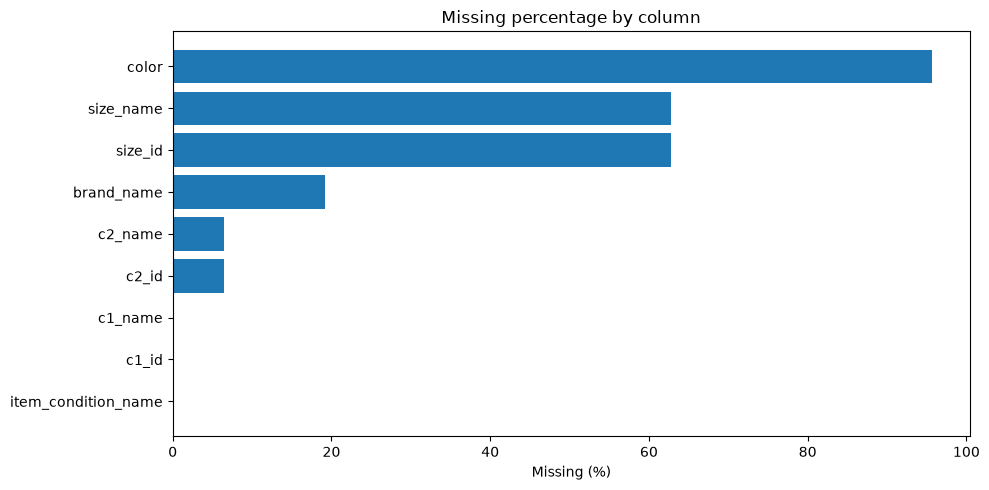

In [14]:
analysis_cols = [
    c for c in raw_columns
    if c not in {"filename", "file_row_number"}
]

missing_sql = ",\n".join(
    f'sum(CASE WHEN "{c}" IS NULL THEN 1 ELSE 0 END) AS "{c}"'
    for c in analysis_cols
)

missing_raw = q(f"SELECT {missing_sql} FROM raw")

missing = (
    missing_raw.T
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing["missing_pct"] = 100 * missing["missing_count"] / N
missing = missing.sort_values("missing_pct", ascending=False)

show_table("03_missing", missing)

plot_missing = missing[missing["missing_pct"] > 0].sort_values("missing_pct")

plt.figure(figsize=(10, max(5, len(plot_missing)*0.35)))
plt.barh(plot_missing["column"], plot_missing["missing_pct"])
plt.xlabel("Missing (%)")
plt.title("Missing percentage by column")
savefig("03_missing_percentage")

## 3.2 ID, timestamp, price, duplicate theo khóa

In [15]:
timestamp_quality = q(f"""
SELECT count(*) AS total_rows,
    count(*) FILTER (WHERE stime IS NULL) AS source_timestamp_null,
    count(*) FILTER (WHERE stime IS NOT NULL AND ({ts_sql}) IS NULL) AS parse_failed
FROM raw
""")
show_table('03_timestamp_parse_quality', timestamp_quality)

quality = q("""
SELECT
    count(*) FILTER (WHERE user_id IS NULL) AS user_null,
    count(*) FILTER (WHERE item_id IS NULL) AS item_null,
    count(*) FILTER (WHERE event_id IS NULL) AS event_null,
    count(*) FILTER (WHERE ts IS NULL) AS timestamp_null,

    count(*) FILTER (WHERE TRY_CAST(user_id AS BIGINT) < 0) AS negative_user_id,
    count(*) FILTER (WHERE TRY_CAST(item_id AS BIGINT) < 0) AS negative_item_id,
    count(*) FILTER (WHERE TRY_CAST(user_id AS BIGINT) = 0) AS zero_user_id,
    count(*) FILTER (WHERE TRY_CAST(item_id AS BIGINT) = 0) AS zero_item_id,

    count(*) FILTER (
        WHERE ts < TIMESTAMP '2023-05-01'
           OR ts >= TIMESTAMP '2023-06-01'
    ) AS timestamp_outside_may,

    count(*) FILTER (WHERE price IS NULL) AS price_null,
    count(*) FILTER (WHERE price <= 0) AS price_nonpositive
FROM events
""")

show_table("03_quality_core", quality)

# Duplicate theo giá trị gốc; không gộp các thời điểm khác nhau vì parse thành NULL.
dup_key = q("""
SELECT
    count(*) AS duplicate_groups,
    coalesce(sum(n - 1), 0) AS duplicate_extra_rows
FROM (
    SELECT user_id, item_id, event_id, stime, count(*) AS n
    FROM raw
    GROUP BY 1,2,3,4
    HAVING count(*) > 1
)
""")

show_table("03_duplicate_key", dup_key)

03_timestamp_parse_quality: 1 dòng


,total_rows,source_timestamp_null,parse_failed
0,174872167,0,0


03_quality_core: 1 dòng


,user_null,item_null,event_null,timestamp_null,negative_user_id,negative_item_id,zero_user_id,zero_item_id,timestamp_outside_may,price_null,price_nonpositive
0,0,0,0,0,0,0,0,0,0,0,0


03_duplicate_key: 1 dòng


,duplicate_groups,duplicate_extra_rows
0,136911,152779.0


,duplicate_groups,duplicate_extra_rows
0,136911,152779.0


## 3.3 Kiểm tra nặng — tùy chọn

In [16]:
if RUN_HEAVY:
    cols = ", ".join(f'"{c}"' for c in analysis_cols)

    exact_dup = q(f"""
    SELECT
        count(*) AS duplicate_groups,
        sum(n - 1) AS duplicate_extra_rows
    FROM (
        SELECT {cols}, count(*) AS n
        FROM raw
        GROUP BY {cols}
        HAVING count(*) > 1
    )
    """)
    show_table("03_exact_duplicates", exact_dup)

    metadata_conflict = q("""
    SELECT
        count(*) FILTER (WHERE name_n > 1) AS item_name_conflict,
        count(*) FILTER (WHERE brand_n > 1) AS brand_conflict,
        count(*) FILTER (WHERE c0_n > 1) AS category0_conflict,
        count(*) FILTER (WHERE c1_n > 1) AS category1_conflict,
        count(*) FILTER (WHERE c2_n > 1) AS category2_conflict
    FROM (
        SELECT
            item_id,
            count(DISTINCT name) AS name_n,
            count(DISTINCT brand) AS brand_n,
            count(DISTINCT category0) AS c0_n,
            count(DISTINCT category1) AS c1_n,
            count(DISTINCT category2) AS c2_n
        FROM events
        WHERE item_id IS NOT NULL
        GROUP BY item_id
    )
    """)
    show_table("03_metadata_conflict", metadata_conflict)
else:
    print("⏭️ RUN_HEAVY=False: bỏ qua exact duplicate toàn row và metadata conflict.")

⏭️ RUN_HEAVY=False: bỏ qua exact duplicate toàn row và metadata conflict.


# 4. Event EDA

04_event_distribution: 6 dòng


,event_id,event_group,interactions,pct,unique_users,unique_items,interactions_per_user
0,item_view,view,147856790,84.551357,2721628,29535089,54.326598
1,item_like,like,22271899,12.736103,1465953,9653364,15.192778
2,item_add_to_cart_tap,other,2895617,1.655848,630053,1952842,4.595831
3,offer_make,other,1224425,0.700183,473307,986847,2.586957
4,buy_start,buy_start,432120,0.247106,171180,253233,2.524360
5,buy_comp,buy_comp,191316,0.109403,133061,190505,1.437807


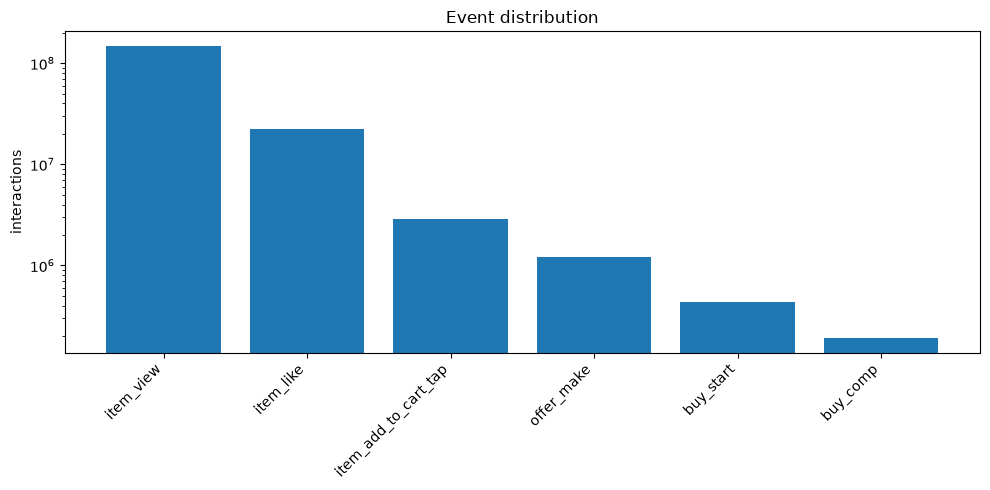

In [17]:
event_stats = q("""
SELECT
    event_id,
    event_group,
    count(*) AS interactions,
    100.0*count(*)/sum(count(*)) OVER () AS pct,
    count(DISTINCT user_id) AS unique_users,
    count(DISTINCT item_id) AS unique_items,
    count(*)*1.0/nullif(count(DISTINCT user_id), 0) AS interactions_per_user
FROM events
GROUP BY 1,2
ORDER BY interactions DESC
""")

show_table("04_event_distribution", event_stats)

bar(
    event_stats,
    "event_id", "interactions",
    "Event distribution",
    "04_event_distribution",
    log_y=True
)

In [18]:
funnel = q("""
SELECT
    event_group,
    count(*) AS interactions,
    count(DISTINCT user_id) AS users,
    count(DISTINCT item_id) AS items
FROM events
WHERE event_group IN ('view','like','cart','buy_start','buy_comp')
GROUP BY event_group
ORDER BY
    CASE event_group
        WHEN 'view' THEN 1
        WHEN 'like' THEN 2
        WHEN 'cart' THEN 3
        WHEN 'buy_start' THEN 4
        WHEN 'buy_comp' THEN 5
    END
""")

show_table("04_funnel_proxy", funnel)

f = dict(zip(funnel["event_group"], funnel["interactions"]))
view, cart, buy = f.get("view", 0), f.get("cart", 0), f.get("buy_comp", 0)

conversion = pd.DataFrame({
    "metric": ["cart/view", "buy_comp/view", "buy_comp/cart"],
    "ratio": [
        cart/view if view else np.nan,
        buy/view if view else np.nan,
        buy/cart if cart else np.nan
    ]
})

show_table("04_conversion_proxy", conversion)

04_funnel_proxy: 4 dòng


,event_group,interactions,users,items
0,view,147856790,2721628,29535089
1,like,22271899,1465953,9653364
2,buy_start,432120,171180,253233
3,buy_comp,191316,133061,190505


04_conversion_proxy: 3 dòng


,metric,ratio
0,cart/view,0.000000
1,buy_comp/view,0.001294
2,buy_comp/cart,NaN


,metric,ratio
0,cart/view,0.000000
1,buy_comp/view,0.001294
2,buy_comp/cart,NaN


# 5. User behavior

In [19]:
con.execute("""
CREATE OR REPLACE TABLE user_stats AS
SELECT
    user_id,
    count(*) AS interactions,
    count(DISTINCT item_id) AS unique_items,
    count(DISTINCT session_id) AS sessions,
    count(DISTINCT sequence_id) AS sequences,
    count(*) FILTER (WHERE event_group='buy_comp') AS purchases,
    count(*) FILTER (
        WHERE event_group IN ('like','cart','buy_start','buy_comp')
    ) AS strong_events
FROM events
WHERE user_id IS NOT NULL
GROUP BY user_id
""")

user_summary = q("""
SELECT
    count(*) AS users,
    avg(interactions) AS mean,
    median(interactions) AS median,
    quantile_cont(interactions, .75) AS p75,
    quantile_cont(interactions, .90) AS p90,
    quantile_cont(interactions, .95) AS p95,
    quantile_cont(interactions, .99) AS p99,
    max(interactions) AS max
FROM user_stats
""")

show_table("05_user_summary", user_summary)

user_thresholds = q("""
SELECT
    100*avg((interactions=1)::INT) AS pct_eq_1,
    100*avg((interactions<3)::INT) AS pct_lt_3,
    100*avg((interactions<5)::INT) AS pct_lt_5,
    100*avg((interactions<8)::INT) AS pct_lt_8,
    100*avg((interactions<10)::INT) AS pct_lt_10
FROM user_stats
""")

show_table("05_user_thresholds", user_thresholds)

RuntimeError: Query interrupted

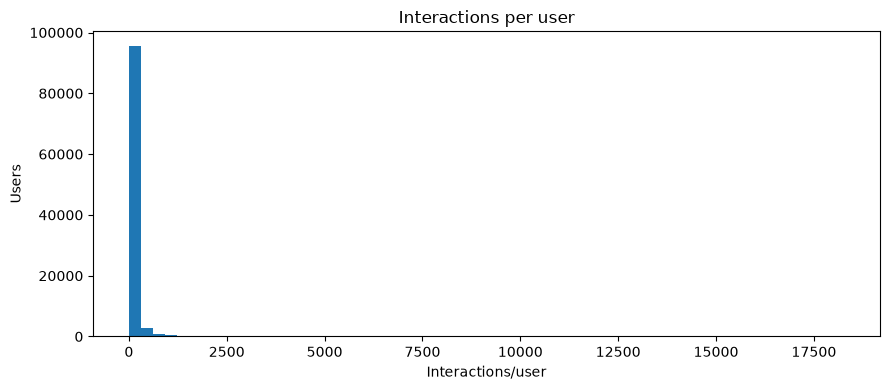

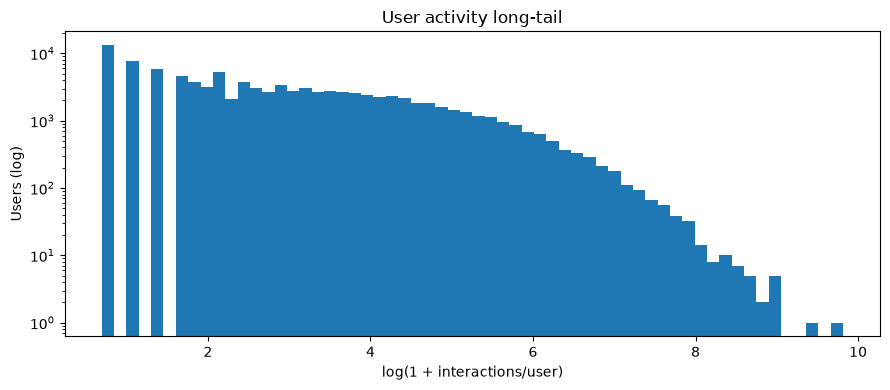

In [ ]:
user_plot = q("""
SELECT interactions
FROM user_stats
USING SAMPLE 100000 ROWS
""")

plt.figure(figsize=(9,4))
plt.hist(user_plot["interactions"], bins=60)
plt.xlabel("Interactions/user")
plt.ylabel("Users")
plt.title("Interactions per user")
savefig("05_user_interactions_hist")

plt.figure(figsize=(9,4))
plt.hist(np.log1p(user_plot["interactions"]), bins=60)
plt.yscale("log")
plt.xlabel("log(1 + interactions/user)")
plt.ylabel("Users (log)")
plt.title("User activity long-tail")
savefig("05_user_interactions_log")

05_top_users: 20 dòng


,user_id,interactions,unique_items,sessions,sequences,purchases,strong_events
0,50727525,29597,22528,250,1348,0,4574
1,32736302,20748,13253,367,948,0,9177
2,14099196,18275,11372,555,835,1,1503
3,8300879,18059,15808,437,825,0,692
4,45748458,17976,13273,186,819,0,3108
5,13100123,15993,8446,389,728,23,8409
6,47956439,15270,11047,537,696,0,3325
7,26165204,14831,10173,452,680,6,2737
8,7619324,14452,6810,167,659,2,7684
9,32599987,14184,9433,234,648,0,5371


05_buyer_vs_nonbuyer: 2 dòng


,user_type,users,avg_interactions,median_interactions,avg_unique_items,avg_sessions
0,buyer,133061,114.010875,10.0,76.740518,18.286688
1,non_buyer,2632802,60.658479,12.0,45.587156,12.306075


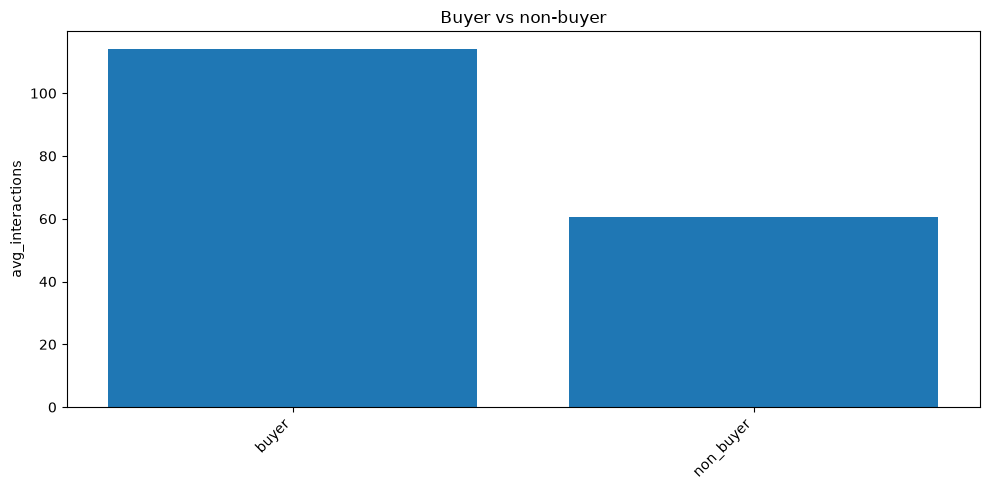

In [ ]:
show_table(
    "05_top_users",
    q("SELECT * FROM user_stats ORDER BY interactions DESC LIMIT 20")
)

buyer_compare = q("""
SELECT
    CASE WHEN purchases>0 THEN 'buyer' ELSE 'non_buyer' END AS user_type,
    count(*) AS users,
    avg(interactions) AS avg_interactions,
    median(interactions) AS median_interactions,
    avg(unique_items) AS avg_unique_items,
    avg(sessions) AS avg_sessions
FROM user_stats
GROUP BY 1
""")

show_table("05_buyer_vs_nonbuyer", buyer_compare)

bar(
    buyer_compare,
    "user_type", "avg_interactions",
    "Buyer vs non-buyer",
    "05_buyer_vs_nonbuyer"
)

# 6. Item behavior

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE item_stats AS
SELECT
    item_id,
    count(*) AS interactions,
    count(DISTINCT user_id) AS unique_users,
    count(*) FILTER (WHERE event_group='view') AS views,
    count(*) FILTER (WHERE event_group='like') AS likes,
    count(*) FILTER (WHERE event_group='cart') AS carts,
    count(*) FILTER (WHERE event_group='buy_comp') AS buys
FROM events
WHERE item_id IS NOT NULL
GROUP BY item_id
""")

item_summary = q("""
SELECT
    count(*) AS items,
    avg(interactions) AS mean,
    median(interactions) AS median,
    quantile_cont(interactions,.95) AS p95,
    quantile_cont(interactions,.99) AS p99,
    max(interactions) AS max
FROM item_stats
""")

show_table("06_item_summary", item_summary)

cold_items = q("""
SELECT
    100*avg((interactions<2)::INT) AS pct_lt_2,
    100*avg((interactions<5)::INT) AS pct_lt_5,
    100*avg((interactions<10)::INT) AS pct_lt_10,
    count(*) FILTER (
        WHERE views>0 AND likes=0 AND carts=0 AND buys=0
    ) AS view_only_items
FROM item_stats
""")

show_table("06_cold_items", cold_items)

06_item_summary: 1 dòng


,items,mean,median,p95,p99,max
0,30054040,5.818591,2.0,22.0,57.0,1883


06_cold_items: 1 dòng


,pct_lt_2,pct_lt_5,pct_lt_10,view_only_items
0,38.801163,71.165504,85.588144,20339783


,pct_lt_2,pct_lt_5,pct_lt_10,view_only_items
0,38.801163,71.165504,85.588144,20339783


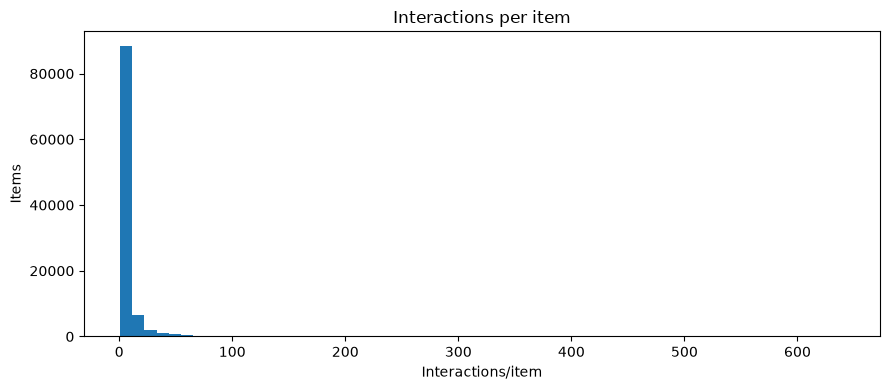

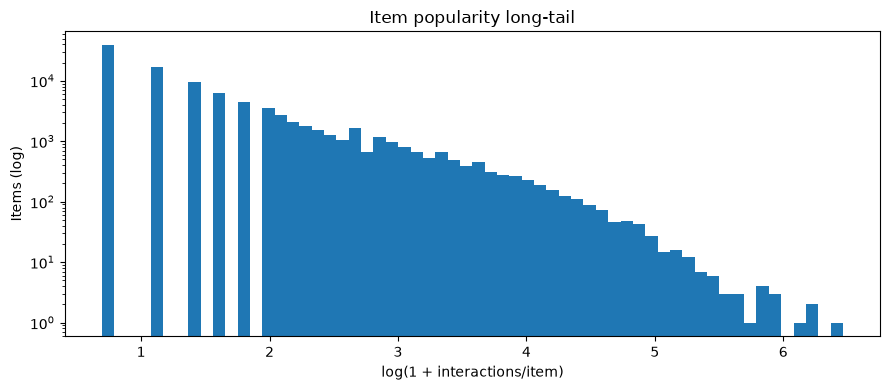

In [ ]:
item_plot = q("""
SELECT interactions
FROM item_stats
USING SAMPLE 100000 ROWS
""")

plt.figure(figsize=(9,4))
plt.hist(item_plot["interactions"], bins=60)
plt.xlabel("Interactions/item")
plt.ylabel("Items")
plt.title("Interactions per item")
savefig("06_item_interactions_hist")

plt.figure(figsize=(9,4))
plt.hist(np.log1p(item_plot["interactions"]), bins=60)
plt.yscale("log")
plt.xlabel("log(1 + interactions/item)")
plt.ylabel("Items (log)")
plt.title("Item popularity long-tail")
savefig("06_item_interactions_log")

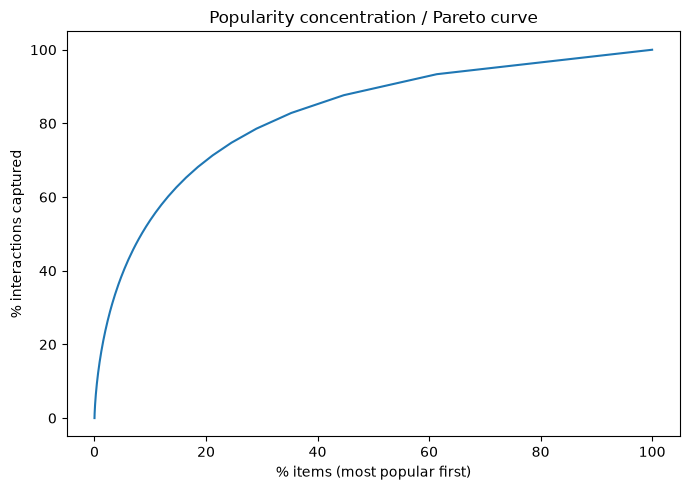

06_top_items: 100 dòng


,item_id,interactions,unique_users,views,likes,carts,buys,buy_view_ratio
0,31232418,1883,1258,1726,147,0,0,0.000000
1,233858127,1819,1007,1704,102,0,0,0.000000
2,170090739,1522,299,932,208,0,0,0.000000
3,199825945,1481,690,1241,196,0,0,0.000000
4,157875024,1349,1162,1329,19,0,0,0.000000
5,189459125,1248,789,1150,86,0,0,0.000000
6,223984650,1239,967,1178,54,0,0,0.000000
7,175157974,1229,914,1208,20,0,0,0.000000
8,127650015,1184,901,1094,84,0,0,0.000000
9,238852844,1170,1092,1142,11,0,1,0.000876


,item_id,interactions,unique_users,views,likes,carts,buys,buy_view_ratio
0,31232418,1883,1258,1726,147,0,0,0.0
1,233858127,1819,1007,1704,102,0,0,0.0
2,170090739,1522,299,932,208,0,0,0.0
3,199825945,1481,690,1241,196,0,0,0.0
4,157875024,1349,1162,1329,19,0,0,0.0
...,...,...,...,...,...,...,...,...
95,33075950,692,402,613,69,0,0,0.0
96,174132044,691,501,631,54,0,0,0.0
97,144740867,689,345,621,60,0,0,0.0
98,171754994,689,431,619,67,0,0,0.0


In [ ]:
popularity = q("""
WITH ranked AS (
    SELECT
        interactions,
        row_number() OVER (ORDER BY interactions DESC) AS rn,
        count(*) OVER () AS n_items,
        sum(interactions) OVER () AS total_interactions
    FROM item_stats
)
SELECT
    100.0*rn/n_items AS pct_items,
    100.0*sum(interactions) OVER (
        ORDER BY rn ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    )/total_interactions AS pct_interactions
FROM ranked
ORDER BY rn
""")

plt.figure(figsize=(7,5))
plt.plot(popularity["pct_items"], popularity["pct_interactions"])
plt.xlabel("% items (most popular first)")
plt.ylabel("% interactions captured")
plt.title("Popularity concentration / Pareto curve")
savefig("06_popularity_pareto")

top_items = q("""
SELECT
    item_id, interactions, unique_users, views, likes, carts, buys,
    buys*1.0/nullif(views,0) AS buy_view_ratio
FROM item_stats
ORDER BY interactions DESC
LIMIT 100
""")

show_table("06_top_items", top_items)

# 7. Session EDA

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE session_stats AS
SELECT
    user_id,
    session_id,
    count(*) AS interactions,
    count(DISTINCT item_id) AS unique_items,
    count(DISTINCT event_id) AS event_types,
    min(ts) AS start_time,
    max(ts) AS end_time,
    count(ts) AS valid_timestamps,
    count(*) - count(ts) AS missing_timestamps,
    CASE WHEN count(ts) = count(*)
         THEN date_diff('second', min(ts), max(ts))
    END AS duration_sec,
    max((event_group='cart')::INT) AS has_cart,
    max((event_group='buy_comp')::INT) AS has_purchase,
    min((event_group='view')::INT) AS view_only
FROM events
WHERE user_id IS NOT NULL
  AND session_id IS NOT NULL
GROUP BY user_id, session_id
""")

session_summary = q("""
SELECT
    count(*) AS sessions,
    count(*) FILTER (WHERE missing_timestamps > 0) AS sessions_missing_timestamps,
    count(duration_sec) AS sessions_with_valid_duration,
    avg(interactions) AS mean_length,
    median(interactions) AS median_length,
    quantile_cont(interactions,.95) AS p95_length,
    quantile_cont(interactions,.99) AS p99_length,
    max(interactions) AS max_length,
    median(duration_sec) AS median_duration_sec,
    quantile_cont(duration_sec,.95) AS p95_duration_sec,
    quantile_cont(duration_sec,.99) AS p99_duration_sec,
    100*avg(has_cart) AS pct_has_cart,
    100*avg(has_purchase) AS pct_has_purchase,
    100*avg(view_only) AS pct_view_only
FROM session_stats
""")

show_table("07_session_summary", session_summary)

07_session_summary: 1 dòng


,sessions,sessions_missing_timestamps,sessions_with_valid_duration,mean_length,median_length,p95_length,p99_length,max_length,median_duration_sec,p95_duration_sec,p99_duration_sec,pct_has_cart,pct_has_purchase,pct_view_only
0,34832704,0,34832704,5.020344,2.0,18.0,39.0,1524,37.0,890.0,1696.0,0.0,0.497871,70.525544


,sessions,sessions_missing_timestamps,sessions_with_valid_duration,mean_length,median_length,p95_length,p99_length,max_length,median_duration_sec,p95_duration_sec,p99_duration_sec,pct_has_cart,pct_has_purchase,pct_view_only
0,34832704,0,34832704,5.020344,2.0,18.0,39.0,1524,37.0,890.0,1696.0,0.0,0.497871,70.525544


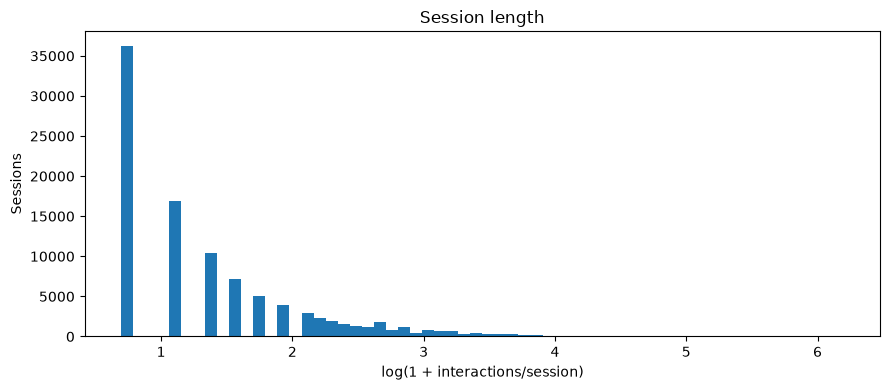

Duration hợp lệ trong mẫu: 100,000/100,000 sessions


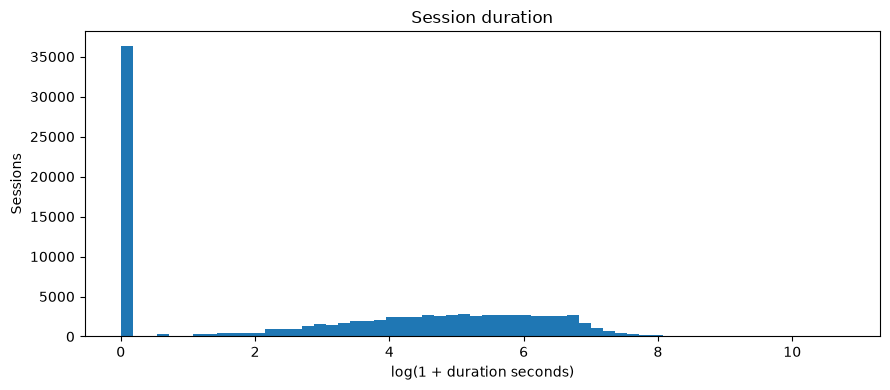

07_session_purchase_compare: 2 dòng


,session_type,sessions,avg_interactions,avg_unique_items,avg_duration_sec
0,non_purchased,34659282,5.006201,4.348023,200.565097
1,purchased,173422,7.846957,4.135294,530.786780


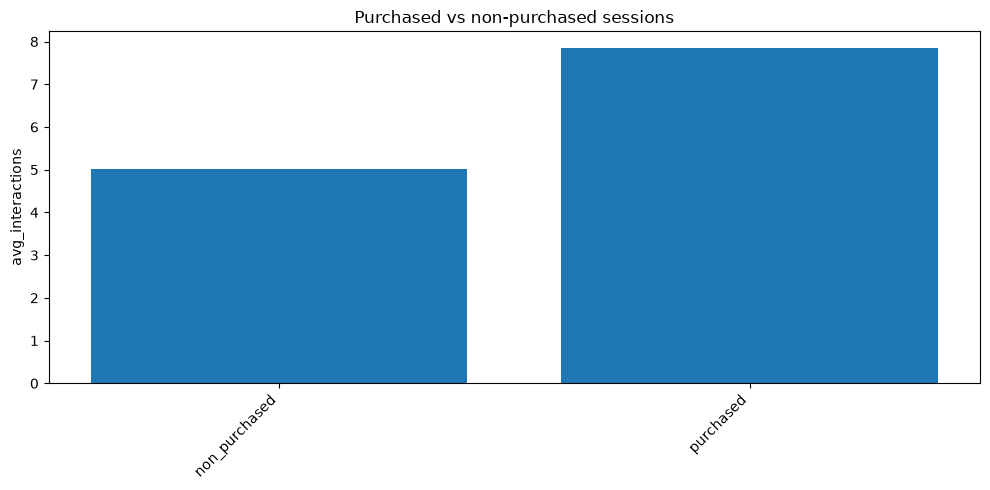

In [ ]:
session_plot = q("""
SELECT interactions, duration_sec, has_purchase
FROM session_stats
USING SAMPLE 100000 ROWS
""")

plt.figure(figsize=(9,4))
plt.hist(np.log1p(session_plot["interactions"]), bins=60)
plt.xlabel("log(1 + interactions/session)")
plt.ylabel("Sessions")
plt.title("Session length")
savefig("07_session_length")

duration_values = pd.to_numeric(session_plot['duration_sec'], errors='coerce')
duration_values = duration_values.to_numpy(dtype=float, na_value=np.nan)
valid_duration = duration_values[np.isfinite(duration_values) & (duration_values >= 0)]
print(f'Duration hợp lệ trong mẫu: {len(valid_duration):,}/{len(duration_values):,} sessions')
if valid_duration.size:
    plt.figure(figsize=(9, 4))
    plt.hist(np.log1p(valid_duration), bins=60)
    plt.xlabel('log(1 + duration seconds)')
    plt.ylabel('Sessions')
    plt.title('Session duration')
    savefig('07_session_duration')
else:
    print('Không vẽ duration: mẫu không có giá trị hợp lệ. Xem 03_timestamp_parse_quality và 07_session_summary.')

session_compare = q("""
SELECT
    CASE WHEN has_purchase=1 THEN 'purchased' ELSE 'non_purchased' END AS session_type,
    count(*) AS sessions,
    avg(interactions) AS avg_interactions,
    avg(unique_items) AS avg_unique_items,
    avg(duration_sec) AS avg_duration_sec
FROM session_stats
GROUP BY 1
""")

show_table("07_session_purchase_compare", session_compare)
bar(
    session_compare,
    "session_type", "avg_interactions",
    "Purchased vs non-purchased sessions",
    "07_purchased_vs_nonpurchased"
)

In [ ]:
reverse_time = q("""
WITH x AS (
    SELECT
        user_id,
        session_id,
        ts,
        lag(ts) OVER (
            PARTITION BY user_id, session_id
            ORDER BY source_file, source_row
        ) AS prev_ts
    FROM events
    WHERE session_id IS NOT NULL
      AND ts IS NOT NULL
)
SELECT count(*) FILTER (WHERE ts < prev_ts) AS reversed_timestamp_rows
FROM x
""")

show_table("07_session_reverse_timestamp", reverse_time)

07_session_reverse_timestamp: 1 dòng


,reversed_timestamp_rows
0,153471


,reversed_timestamp_rows
0,153471


# 8. Sequence EDA — SASRec

In [ ]:
if HAS_SEQUENCE:
    con.execute("""
    CREATE OR REPLACE TABLE sequence_stats AS
    SELECT
        user_id,
        sequence_id,
        count(*) AS actual_length,
        min(declared_length) AS declared_min,
        max(declared_length) AS declared_max,
        count(*) FILTER (WHERE declared_length IS NULL) AS missing_declared_length,
        count(DISTINCT item_id) AS unique_items,
        count(DISTINCT event_id) AS event_diversity,
        count(*) - count(DISTINCT item_id) AS repeated_items
    FROM events
    WHERE user_id IS NOT NULL
      AND sequence_id IS NOT NULL
    GROUP BY user_id, sequence_id
    """)

    sequence_summary = q("""
    SELECT
        count(*) AS sequences,
        avg(actual_length) AS mean,
        median(actual_length) AS median,
        quantile_cont(actual_length,.90) AS p90,
        quantile_cont(actual_length,.95) AS p95,
        quantile_cont(actual_length,.99) AS p99,
        max(actual_length) AS max,
        100*avg((actual_length=1)::INT) AS pct_eq_1,
        100*avg((actual_length<5)::INT) AS pct_lt_5,
        100*avg((actual_length>50)::INT) AS pct_gt_50,
        100*avg((actual_length>100)::INT) AS pct_gt_100
    FROM sequence_stats
    """)

    show_table("08_sequence_summary", sequence_summary)

    mismatch = q("""
    SELECT
        count(*) AS total_sequences,
        count(*) FILTER (
            WHERE declared_max IS NOT NULL
              AND actual_length <> declared_max
        ) AS mismatch_sequences
    FROM sequence_stats
    """)
    show_table("08_sequence_length_mismatch", mismatch)
else:
    print("Dataset không có sequence_id.")

OutOfMemoryException: Out of Memory Error: could not allocate block of size 256.0 KiB (12.4 GiB/12.5 GiB used)

Possible solutions:
* Reducing the number of threads (SET threads=X)
* Disabling insertion-order preservation (SET preserve_insertion_order=false)
* Increasing the memory limit (SET memory_limit='...GB')

See also https://duckdb.org/docs/stable/guides/performance/how_to_tune_workloads

In [ ]:
if HAS_SEQUENCE:
    seq_plot = q("""
    SELECT actual_length
    FROM sequence_stats
    USING SAMPLE 100000 ROWS
    """)

    plt.figure(figsize=(9,4))
    plt.hist(np.log1p(seq_plot["actual_length"]), bins=60)
    plt.xlabel("log(1 + sequence length)")
    plt.ylabel("Sequences")
    plt.title("Sequence length distribution")
    savefig("08_sequence_length")

    seq_per_user = q("""
    SELECT user_id, count(*) AS sequences
    FROM sequence_stats
    GROUP BY user_id
    ORDER BY sequences DESC
    LIMIT 20
    """)

    show_table("08_top_users_by_sequences", seq_per_user)

CatalogException: Catalog Error: Table with name sequence_stats does not exist!
Did you mean "user_stats"?

LINE 3:     FROM sequence_stats
                 ^

**Dùng P95/P99 trong `08_sequence_summary` để chọn `MAX_SEQ_LENGTH` cho SASRec.**  
Không chọn 50 chỉ theo cảm tính.

# 9. Temporal EDA

In [ ]:
daily = q("""
SELECT
    cast(ts AS DATE) AS day,
    count(*) AS interactions,
    count(DISTINCT user_id) AS users,
    count(DISTINCT item_id) AS items,
    count(*) FILTER (WHERE event_group='buy_comp') AS buys,
    count(*) FILTER (WHERE event_group='buy_comp')*1.0
        / nullif(count(*) FILTER (WHERE event_group='view'),0) AS buy_view_ratio
FROM events
WHERE ts IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

hourly = q("""
SELECT
    hour(ts) AS hour,
    count(*) AS interactions,
    count(DISTINCT user_id) AS users
FROM events
WHERE ts IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

dow = q("""
SELECT
    dayofweek(ts) AS day_of_week,
    count(*) AS interactions
FROM events
WHERE ts IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

show_table("09_daily", daily)
show_table("09_hourly", hourly)
show_table("09_day_of_week", dow)

09_daily: 31 dòng


,day,interactions,users,items,buys,buy_view_ratio
0,2023-05-01,6287745,607207,3375418,6944,0.001301
1,2023-05-02,6166691,587269,3349664,6942,0.001328
2,2023-05-03,6128586,579474,3342931,6958,0.001340
3,2023-05-04,5995244,569328,3285243,7024,0.001382
4,2023-05-05,5765926,547043,3198004,6904,0.001413
5,2023-05-06,5662130,530086,3163740,6339,0.001320
6,2023-05-07,6146642,553566,3372104,6409,0.001230
7,2023-05-08,6003083,566209,3290517,6499,0.001277
8,2023-05-09,6025401,565659,3304168,6513,0.001276
9,2023-05-10,5807377,551714,3215535,6456,0.001312


09_hourly: 24 dòng


,hour,interactions,users
0,0,11007524,897665
1,1,12233840,921712
2,2,12453734,893753
3,3,11156639,783410
4,4,8770434,615103
5,5,6343965,453581
6,6,4497082,328100
7,7,3261117,246021
8,8,2547013,202834
9,9,2379780,209533


09_day_of_week: 7 dòng


,day_of_week,interactions
0,0,23700986
1,1,29896465
2,2,29538637
3,3,23311602
4,4,23090892
5,5,22672817
6,6,22660768


,day_of_week,interactions
0,0,23700986
1,1,29896465
2,2,29538637
3,3,23311602
4,4,23090892
5,5,22672817
6,6,22660768


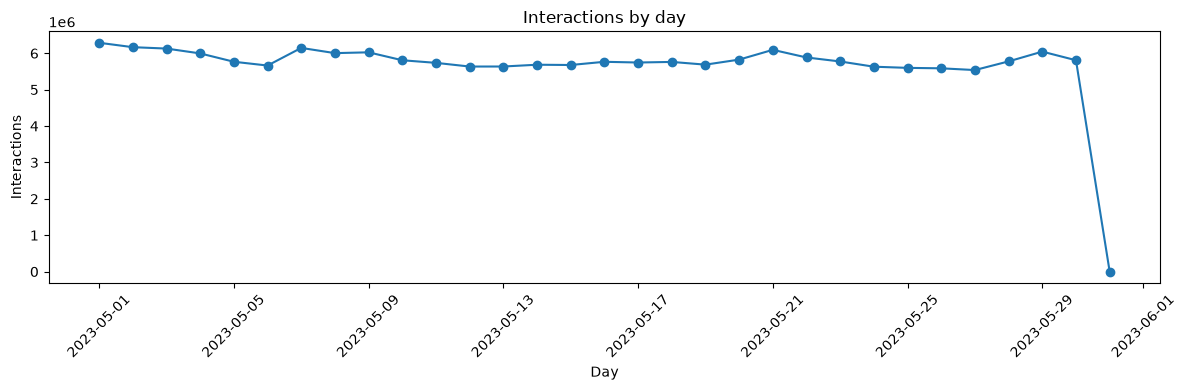

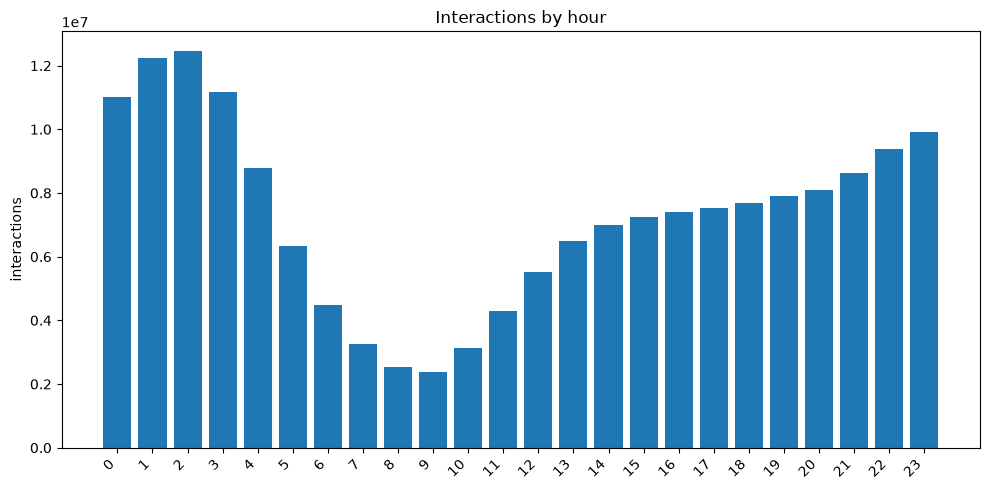

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(pd.to_datetime(daily["day"]), daily["interactions"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Day")
plt.ylabel("Interactions")
plt.title("Interactions by day")
savefig("09_daily_interactions")

bar(
    hourly,
    "hour", "interactions",
    "Interactions by hour",
    "09_hourly_interactions"
)

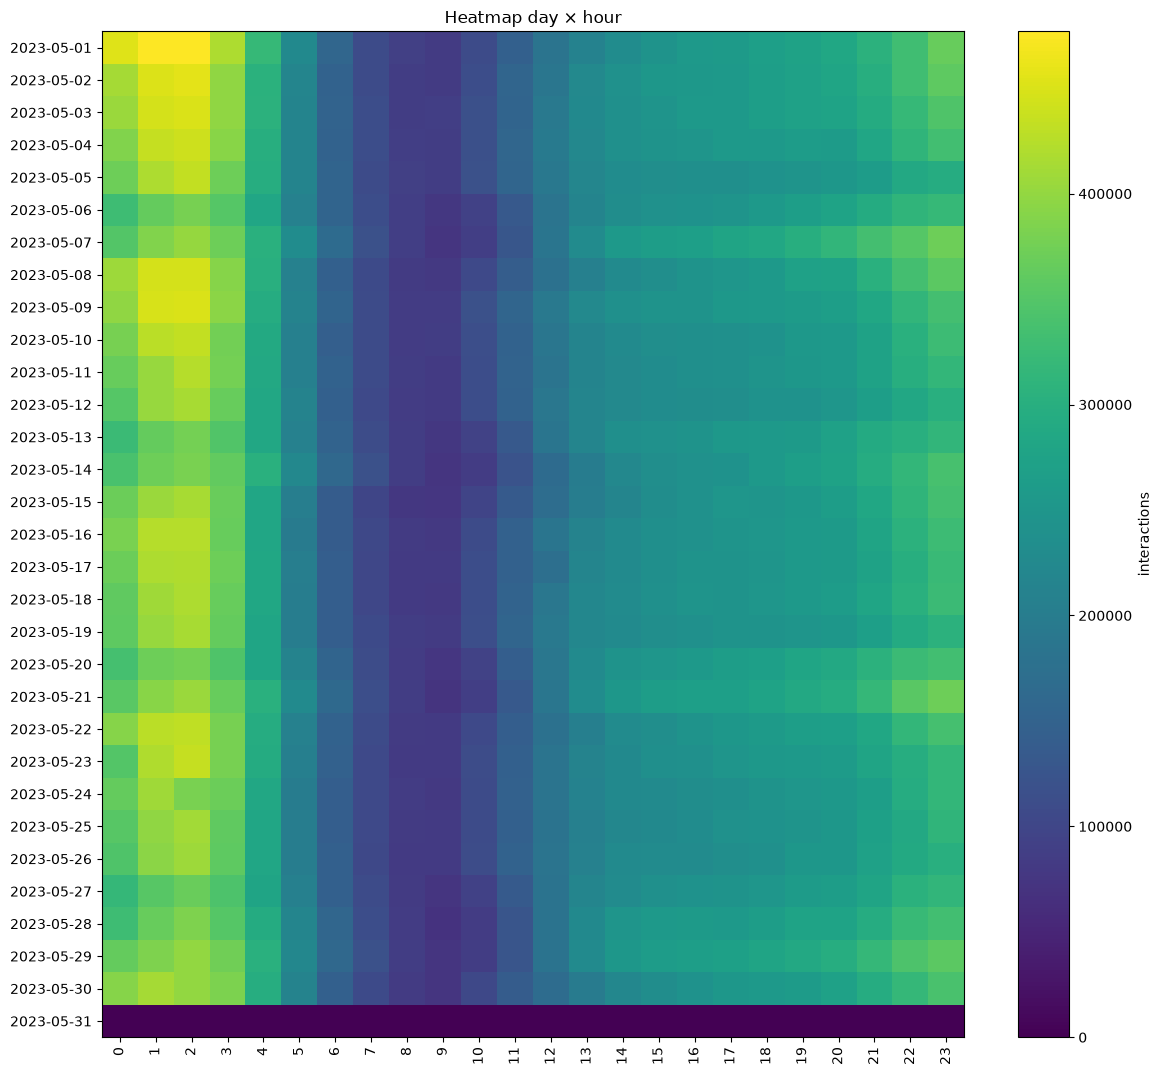

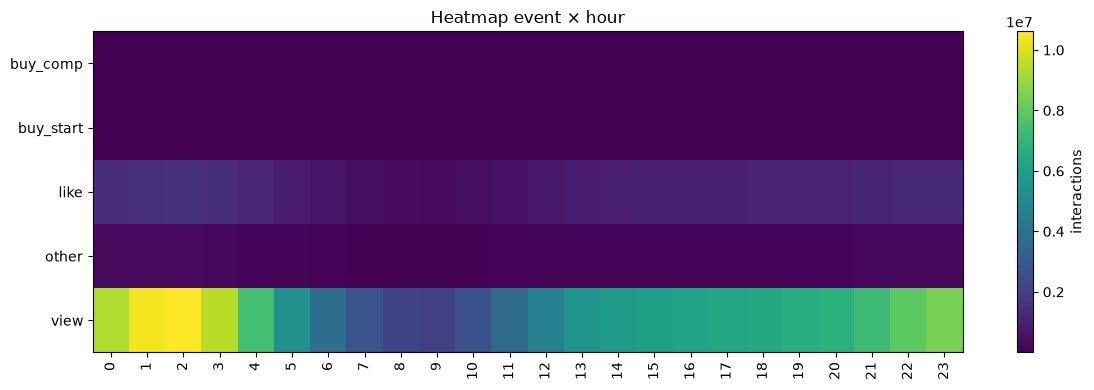

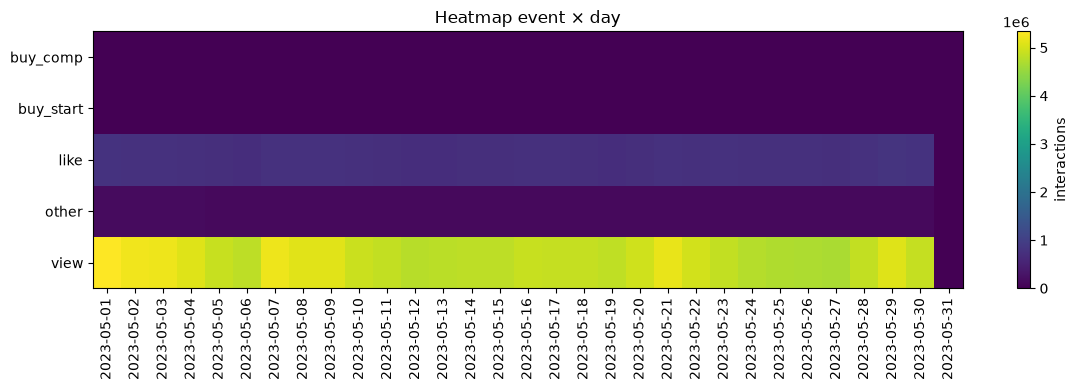

In [ ]:
day_hour = q("""
SELECT cast(ts AS DATE) AS day, hour(ts) AS hour, count(*) AS interactions
FROM events
WHERE ts IS NOT NULL
GROUP BY 1,2
ORDER BY 1,2
""")

event_hour = q("""
SELECT event_group, hour(ts) AS hour, count(*) AS interactions
FROM events
WHERE ts IS NOT NULL
GROUP BY 1,2
""")

event_day = q("""
SELECT event_group, cast(ts AS DATE) AS day, count(*) AS interactions
FROM events
WHERE ts IS NOT NULL
GROUP BY 1,2
""")

heatmap(day_hour, "day", "hour", "interactions",
        "Heatmap day × hour", "09_day_hour_heatmap")

heatmap(event_hour, "event_group", "hour", "interactions",
        "Heatmap event × hour", "09_event_hour_heatmap")

heatmap(event_day, "event_group", "day", "interactions",
        "Heatmap event × day", "09_event_day_heatmap")

In [ ]:
new_users = q("""
WITH x AS (
    SELECT user_id, min(cast(ts AS DATE)) AS first_day
    FROM events
    WHERE user_id IS NOT NULL AND ts IS NOT NULL
    GROUP BY user_id
)
SELECT first_day AS day, count(*) AS new_users
FROM x
GROUP BY 1
ORDER BY 1
""")

new_items = q("""
WITH x AS (
    SELECT item_id, min(cast(ts AS DATE)) AS first_day
    FROM events
    WHERE item_id IS NOT NULL AND ts IS NOT NULL
    GROUP BY item_id
)
SELECT first_day AS day, count(*) AS new_items
FROM x
GROUP BY 1
ORDER BY 1
""")

show_table("09_new_users", new_users)
show_table("09_new_items", new_items)

09_new_users: 30 dòng


,day,new_users
0,2023-05-01,607207
1,2023-05-02,284928
2,2023-05-03,199490
3,2023-05-04,154920
4,2023-05-05,122199
5,2023-05-06,107190
6,2023-05-07,103906
7,2023-05-08,91564
8,2023-05-09,83007
9,2023-05-10,73633


09_new_items: 31 dòng


,day,new_items
0,2023-05-01,3375418
1,2023-05-02,2332097
2,2023-05-03,1918893
3,2023-05-04,1627922
4,2023-05-05,1413143
5,2023-05-06,1281948
6,2023-05-07,1285172
7,2023-05-08,1146866
8,2023-05-09,1088264
9,2023-05-10,990494


,day,new_items
0,2023-05-01,3375418
1,2023-05-02,2332097
2,2023-05-03,1918893
3,2023-05-04,1627922
4,2023-05-05,1413143
5,2023-05-06,1281948
6,2023-05-07,1285172
7,2023-05-08,1146866
8,2023-05-09,1088264
9,2023-05-10,990494


# 10. Product metadata EDA

In [ ]:
metadata_tables = {}

for col in [
    "category0", "category1", "category2",
    "brand", "condition", "shipper", "size", "color"
]:
    df = q(f"""
    SELECT
        {col},
        count(*) AS interactions,
        count(DISTINCT item_id) AS items,
        count(DISTINCT product_id) AS products
    FROM events
    WHERE {col} IS NOT NULL
    GROUP BY 1
    ORDER BY interactions DESC
    LIMIT 30
    """)
    metadata_tables[col] = df
    show_table(f"10_top_{col}", df)

10_top_category0: 17 dòng


,category0,interactions,items,products
0,Women,59154207,10988602,308081
1,Toys & Collectibles,32901840,5097700,71021
2,Men,15672537,2854648,100988
3,Kids,12920630,2176091,68163
4,Electronics,12126857,1693545,45788
5,Beauty,10515849,1511481,37658
6,Home,10441900,2064136,96916
7,Vintage & collectibles,7753667,1549348,66969
8,Books,3276580,616076,13345
9,Other,3006487,454043,28187


10_top_category1: 30 dòng


,category1,interactions,items,products
0,Shoes,13440219,2199868,37883
1,Women's handbags,8514951,997187,20685
2,Collectibles & Hobbies,8400629,1332458,14496
3,Athletic apparel,7587206,1263959,38879
4,Dresses,7358725,1339408,27972
5,Tops & blouses,7290223,1714058,39001
6,Action Figures & Accessories,6936783,897351,4784
7,Jewelry,6328178,1280902,18315
8,Dolls & Accessories,4320072,462934,5271
9,Video games & consoles,4313002,526430,4717


RuntimeError: Query interrupted

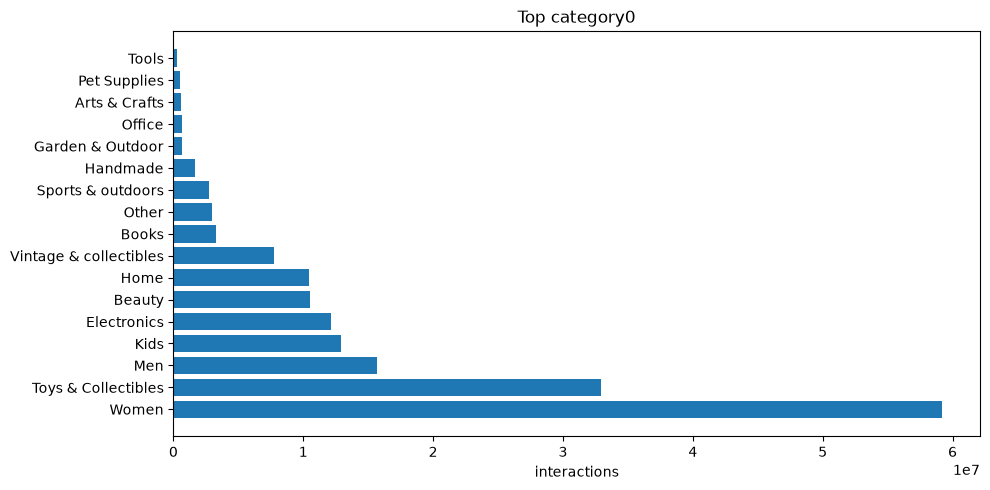

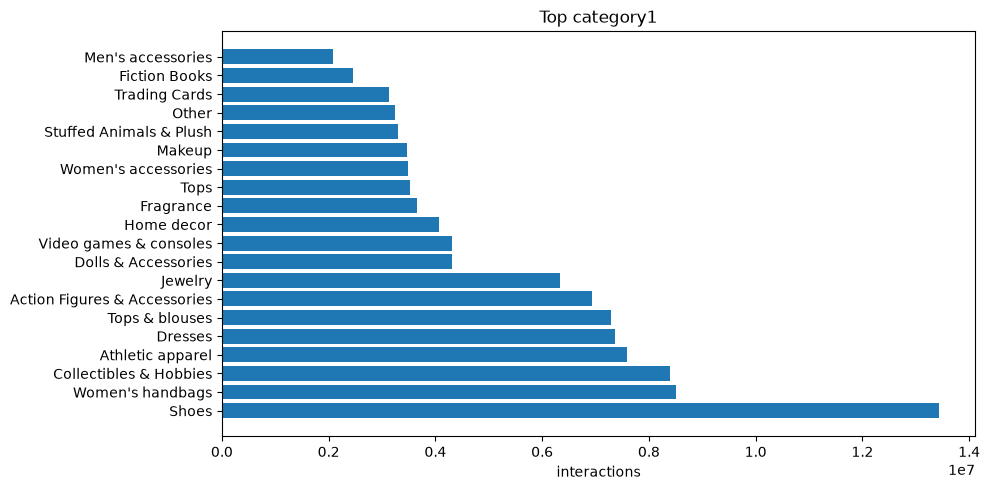

KeyError: 'category2'

In [ ]:
for col in ["category0", "category1", "category2", "brand"]:
    df = metadata_tables[col].head(20).sort_values("interactions")
    if not df.empty:
        bar(
            df,
            col, "interactions",
            f"Top {col}",
            f"10_top_{col}",
            horizontal=True
        )

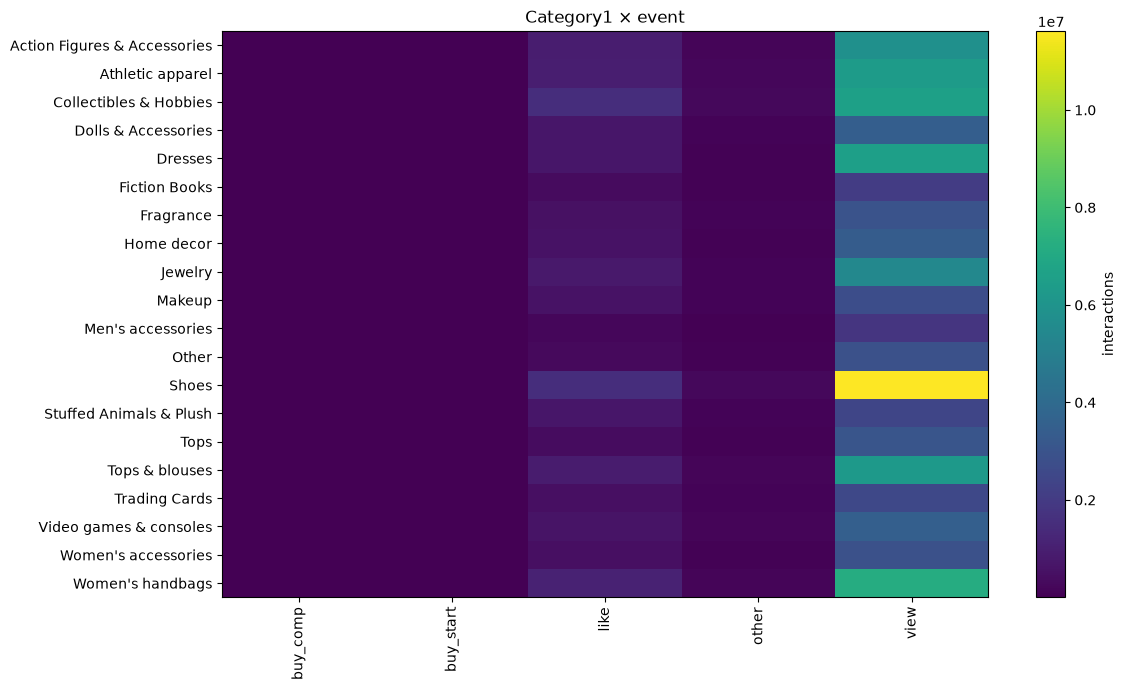

10_category_conversion: 30 dòng


,category1,views,buys,conversion
0,Outdoor Waste & Composting,793,21,0.026482
1,Automotive Oils & Fluids,1804,23,0.012749
2,Sauna & Hot Tub Equipment,1288,12,0.009317
3,Ink & Toner,25338,153,0.006038
4,Christian books & bibles,195,1,0.005128
5,Book,586,3,0.005119
6,Watering Equipment,10446,45,0.004308
7,Reference Books,215397,905,0.004202
8,Art Studio Furniture,991,4,0.004036
9,Smart Home & Security,135431,513,0.003788


,category1,views,buys,conversion
0,Outdoor Waste & Composting,793,21,0.026482
1,Automotive Oils & Fluids,1804,23,0.012749
2,Sauna & Hot Tub Equipment,1288,12,0.009317
3,Ink & Toner,25338,153,0.006038
4,Christian books & bibles,195,1,0.005128
5,Book,586,3,0.005119
6,Watering Equipment,10446,45,0.004308
7,Reference Books,215397,905,0.004202
8,Art Studio Furniture,991,4,0.004036
9,Smart Home & Security,135431,513,0.003788


In [ ]:
category_event = q("""
WITH top_categories AS (
    SELECT category1
    FROM events
    WHERE category1 IS NOT NULL
    GROUP BY category1
    ORDER BY count(*) DESC
    LIMIT 20
)
SELECT
    e.category1,
    e.event_group,
    count(*) AS interactions
FROM events e
JOIN top_categories t
  ON e.category1=t.category1
GROUP BY 1,2
""")

heatmap(
    category_event,
    "category1", "event_group", "interactions",
    "Category1 × event",
    "10_category_event_heatmap"
)

category_conversion = q("""
SELECT
    category1,
    count(*) FILTER (WHERE event_group='view') AS views,
    count(*) FILTER (WHERE event_group='buy_comp') AS buys,
    count(*) FILTER (WHERE event_group='buy_comp')*1.0
        / nullif(count(*) FILTER (WHERE event_group='view'),0) AS conversion
FROM events
WHERE category1 IS NOT NULL
GROUP BY category1
HAVING count(*) FILTER (WHERE event_group='view') >= 100
ORDER BY conversion DESC
LIMIT 30
""")

show_table("10_category_conversion", category_conversion)

# 11. Price EDA

In [ ]:
price_stats = q("""
SELECT
    count(price) AS valid_price,
    count(*) FILTER (WHERE price IS NULL) AS missing_price,
    count(*) FILTER (WHERE price<=0) AS nonpositive_price,
    min(price) AS min,
    avg(price) AS mean,
    median(price) AS median,
    quantile_cont(price,.25) AS p25,
    quantile_cont(price,.75) AS p75,
    quantile_cont(price,.95) AS p95,
    quantile_cont(price,.99) AS p99,
    max(price) AS max
FROM events
""")

show_table("11_price_stats", price_stats)

q1 = float(price_stats.loc[0, "p25"])
q3 = float(price_stats.loc[0, "p75"])
iqr = q3 - q1
upper_iqr = q3 + 1.5*iqr

price_outliers = q(f"""
SELECT
    count(*) AS outliers_iqr,
    100.0*count()/{N} AS pct_all_rows
FROM events
WHERE price > {upper_iqr}
""")

show_table("11_price_outliers", price_outliers)
print("IQR upper bound:", upper_iqr)

11_price_stats: 1 dòng


,valid_price,missing_price,nonpositive_price,min,mean,median,p25,p75,p95,p99,max
0,174872167,0,0,1.0,62.691689,25.0,13.5,56.0,225.0,636.0,5000.0


11_price_outliers: 1 dòng


,outliers_iqr,pct_all_rows
0,20125498,11.508691


IQR upper bound: 119.75


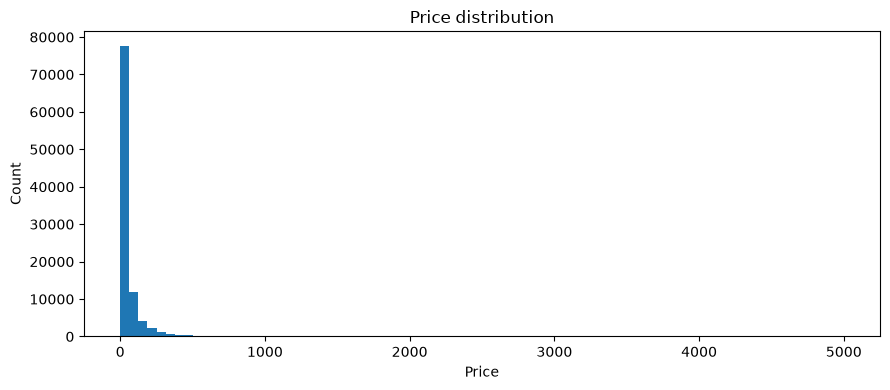

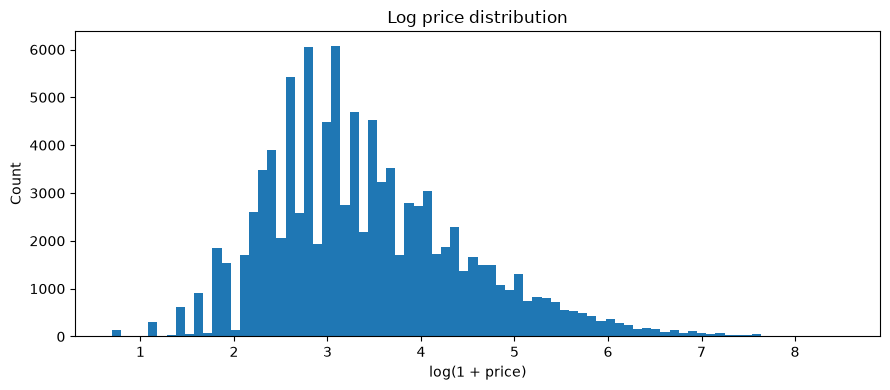

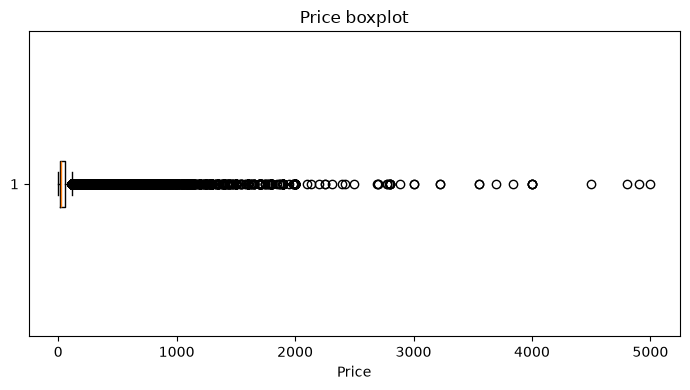

In [ ]:
price_sample = q("""
SELECT price, event_group
FROM (
    SELECT price, event_group
    FROM events
    WHERE price IS NOT NULL
      AND isfinite(price)
      AND price > 0
) AS valid_prices
USING SAMPLE 100000 ROWS
""")

prices = pd.to_numeric(
    price_sample["price"], errors="coerce"
).to_numpy(dtype=float, na_value=np.nan)

prices = prices[np.isfinite(prices) & (prices > 0)]

if prices.size == 0:
    print("Không có giá hợp lệ để vẽ biểu đồ.")
else:
    plt.figure(figsize=(9, 4))
    plt.hist(prices, bins=80)
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.title("Price distribution")
    savefig("11_price_hist")

    plt.figure(figsize=(9, 4))
    plt.hist(np.log1p(prices), bins=80)
    plt.xlabel("log(1 + price)")
    plt.ylabel("Count")
    plt.title("Log price distribution")
    savefig("11_price_log_hist")

    plt.figure(figsize=(7, 4))
    plt.boxplot(prices, vert=False)
    plt.xlabel("Price")
    plt.title("Price boxplot")
    savefig("11_price_boxplot")

11_price_by_event: 5 dòng


,event_group,n,median_price,mean_price
0,buy_start,432120,25.0,54.246179
1,view,147856790,25.0,64.612730
2,like,22271899,24.0,53.897297
3,buy_comp,191316,21.0,41.635174
4,other,4120042,20.0,43.154723


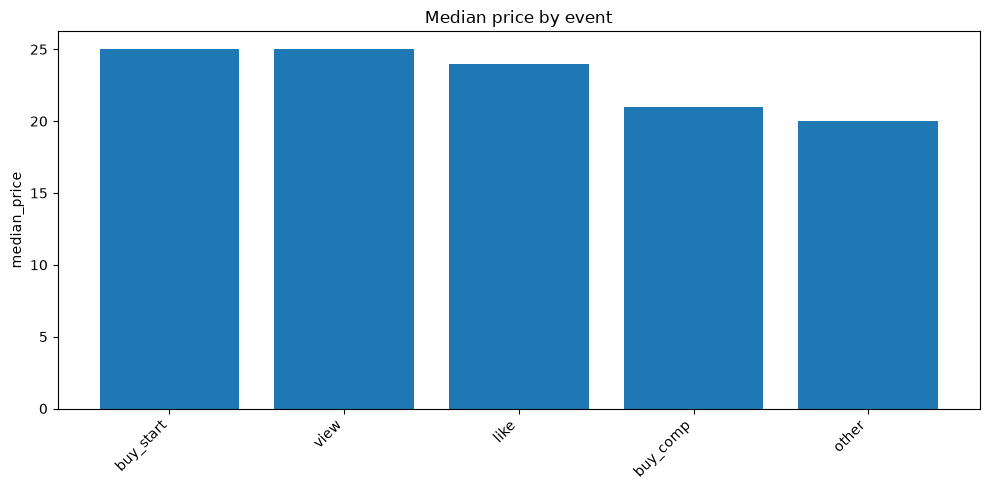

In [ ]:
price_event = q("""
SELECT
    event_group,
    count(price) AS n,
    median(price) AS median_price,
    avg(price) AS mean_price
FROM events
WHERE price > 0
GROUP BY 1
ORDER BY median_price DESC
""")

show_table("11_price_by_event", price_event)

bar(
    price_event,
    "event_group", "median_price",
    "Median price by event",
    "11_price_by_event"
)

# 12. Recommendation-specific diagnostics

## 12.1 Sparsity + repeated interaction

In [ ]:
matrix = q("""
WITH pairs AS (
    SELECT user_id, item_id
    FROM events
    WHERE user_id IS NOT NULL AND item_id IS NOT NULL
    GROUP BY 1,2
),
stats AS (
    SELECT
        count(DISTINCT user_id) AS users,
        count(DISTINCT item_id) AS items
    FROM events
)
SELECT
    stats.users,
    stats.items,
    count(*) AS unique_user_item_pairs,
    count(*)*1.0/(stats.users*stats.items) AS density,
    1-count(*)*1.0/(stats.users*stats.items) AS sparsity
FROM pairs, stats
GROUP BY stats.users, stats.items
""")

show_table("12_matrix_sparsity", matrix)

repeat_ratio = q("""
WITH x AS (
    SELECT
        count(*) AS interactions,
        count(DISTINCT (user_id, item_id)) AS pairs
    FROM events
    WHERE user_id IS NOT NULL AND item_id IS NOT NULL
)
SELECT
    interactions,
    pairs,
    1-pairs*1.0/interactions AS repeated_interaction_ratio
FROM x
""")

show_table("12_repeated_interactions", repeat_ratio)

12_matrix_sparsity: 1 dòng


,users,items,unique_user_item_pairs,density,sparsity
0,2765863,30054040,130233126,0.000002,0.999998


12_repeated_interactions: 1 dòng


,interactions,pairs,repeated_interaction_ratio
0,174872167,130233126,0.255267


,interactions,pairs,repeated_interaction_ratio
0,174872167,130233126,0.255267


## 12.2 3-core / 5-core / 8-core / 10-core

12_k_core_one_pass: 4 dòng


,k,remaining_rows,pct_remaining,pct_removed
0,3,152543054,87.231180,12.768820
1,5,135831371,77.674666,22.325334
2,8,116515107,66.628732,33.371268
3,10,106121407,60.685133,39.314867


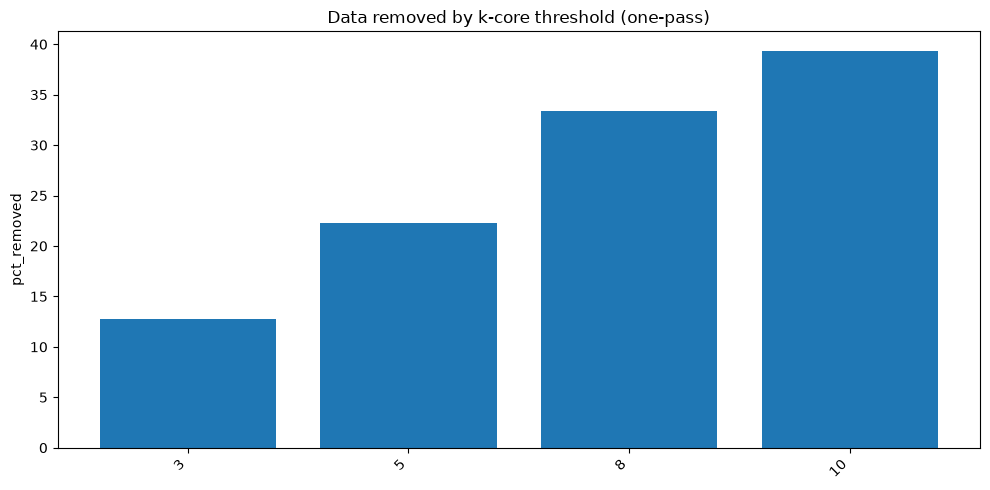

In [ ]:
k_rows = []

for k in [3,5,8,10]:
    row = q(f"""
    WITH good_users AS (
        SELECT user_id
        FROM events
        WHERE user_id IS NOT NULL
        GROUP BY user_id
        HAVING count(*) >= {k}
    ),
    good_items AS (
        SELECT item_id
        FROM events
        WHERE item_id IS NOT NULL
        GROUP BY item_id
        HAVING count(*) >= {k}
    )
    SELECT
        {k} AS k,
        count(*) AS remaining_rows
    FROM events e
    JOIN good_users u USING (user_id)
    JOIN good_items i USING (item_id)
    """).iloc[0].to_dict()

    k_rows.append(row)

k_core = pd.DataFrame(k_rows)
k_core["pct_remaining"] = 100*k_core["remaining_rows"]/N
k_core["pct_removed"] = 100-k_core["pct_remaining"]

show_table("12_k_core_one_pass", k_core)

bar(
    k_core,
    "k", "pct_removed",
    "Data removed by k-core threshold (one-pass)",
    "12_k_core_removed"
)

Đây là **one-pass k-core diagnostic** để đánh giá nhanh.  
Nếu preprocessing cuối cùng yêu cầu k-core đúng nghĩa, có thể viết vòng lặp đến hội tụ sau.

## 12.3 Event transition + time gap

In [ ]:
time_gap = q("""
WITH ordered AS (
    SELECT
        user_id,
        event_group,
        ts,
        date_diff(
            'second',
            lag(ts) OVER (
                PARTITION BY user_id
                ORDER BY ts, source_file, source_row
            ),
            ts
        ) AS gap_sec
    FROM events
    WHERE user_id IS NOT NULL AND ts IS NOT NULL
)
SELECT gap_sec, event_group
FROM ordered
WHERE gap_sec IS NOT NULL AND gap_sec >= 0
USING SAMPLE 200000 ROWS
""")

show_table(
    "12_time_gap_summary",
    time_gap.describe(include="all").reset_index()
)

plt.figure(figsize=(9,4))
plt.hist(np.log1p(time_gap["gap_sec"]), bins=80)
plt.xlabel("log(1 + gap seconds)")
plt.ylabel("Interactions")
plt.title("Time gap between interactions")
savefig("12_time_gap")

## 12.4 Chronological split + unseen user/item

In [ ]:
if pd.Timestamp(TRAIN_END) >= pd.Timestamp(VAL_END):
    raise ValueError("TRAIN_END phải nhỏ hơn VAL_END")

con.execute(f"""
CREATE OR REPLACE VIEW split_events AS
SELECT
    *,
    CASE
        WHEN ts < TIMESTAMP '{TRAIN_END}' THEN 'train'
        WHEN ts < TIMESTAMP '{VAL_END}' THEN 'validation'
        ELSE 'test'
    END AS split
FROM events
WHERE ts IS NOT NULL
""")

split_stats = q("""
SELECT
    split,
    count(*) AS interactions,
    count(DISTINCT user_id) AS users,
    count(DISTINCT item_id) AS items
FROM split_events
GROUP BY split
ORDER BY
    CASE split
        WHEN 'train' THEN 1
        WHEN 'validation' THEN 2
        WHEN 'test' THEN 3
    END
""")

show_table("12_split_stats", split_stats)

CatalogException: Catalog Error: Table with name events does not exist!
Did you mean "pg_views"?

LINE 10: FROM events
              ^

In [ ]:
coverage = q("""
WITH train_users AS (
    SELECT DISTINCT user_id
    FROM split_events
    WHERE split='train'
),
train_items AS (
    SELECT DISTINCT item_id
    FROM split_events
    WHERE split='train'
),
future AS (
    SELECT *
    FROM split_events
    WHERE split IN ('validation','test')
)
SELECT
    split,
    count(*) AS rows,
    count(*) FILTER (WHERE tu.user_id IS NULL) AS rows_unseen_user,
    count(*) FILTER (WHERE ti.item_id IS NULL) AS rows_unseen_item,
    100.0*count(*) FILTER (WHERE tu.user_id IS NULL)/count(*) AS pct_unseen_user,
    100.0*count(*) FILTER (WHERE ti.item_id IS NULL)/count(*) AS pct_unseen_item
FROM future f
LEFT JOIN train_users tu USING (user_id)
LEFT JOIN train_items ti USING (item_id)
GROUP BY split
""")

show_table("12_train_coverage", coverage)

plot_cov = coverage[
    ["split", "pct_unseen_user", "pct_unseen_item"]
].melt(
    id_vars="split",
    var_name="metric",
    value_name="pct"
)

plt.figure(figsize=(8,4))
for metric, g in plot_cov.groupby("metric"):
    plt.plot(g["split"], g["pct"], marker="o", label=metric)
plt.ylabel("%")
plt.title("Unseen users/items vs train")
plt.legend()
savefig("12_unseen_entities")

## 12.5 Most-popular baseline

In [ ]:
popular_items = q("""
SELECT
    item_id,
    count(*) AS train_interactions
FROM split_events
WHERE split='train'
  AND item_id IS NOT NULL
GROUP BY item_id
ORDER BY train_interactions DESC
LIMIT 20
""")

show_table("12_most_popular_top20", popular_items)

print("✅ Giữ baseline này để so với SASRec/GRU4Rec/LightGCN bằng cùng protocol đánh giá.")

# Kết thúc — các bảng nên đọc trước khi train

Ưu tiên:

- `01_structure_summary`: số file, row, dung lượng.
- `03_missing`: missing metadata.
- `04_event_distribution`: event imbalance.
- `05_user_summary` + `05_user_thresholds`: user long-tail.
- `06_item_summary` + `06_cold_items`: item long-tail.
- `07_session_summary`: session.
- `08_sequence_summary`: **P95/P99 để chọn MAX_SEQ_LENGTH**.
- `09_daily`: cơ sở chọn chronological split.
- `12_matrix_sparsity`: độ thưa.
- `12_k_core_one_pass`: 3/5/8/10-core.
- `12_train_coverage`: unseen users/items.

## Pipeline sau EDA

`raw parquet → cleaning/filtering → encode user/item → sort time → sequence → chronological split → baseline → model`

Không train trực tiếp trên toàn bộ 20–23 GB raw metadata.